<div style="background: linear-gradient(135deg, #0D1B2A 0%, #1B4F72 50%, #0D1B2A 100%);
     padding: 50px 40px; border-radius: 16px; text-align: center;
     border: 2px solid #E74C3C; box-shadow: 0 0 40px rgba(231,76,60,0.4);">
  <div style="font-size: 72px; margin-bottom: 10px;">🎮</div>
  <h1 style="color: #F39C12; font-size: 36px; margin: 0; letter-spacing: 3px;
      font-family: 'Courier New', monospace; text-shadow: 0 0 20px #F39C12;">
    VIDEOJUEGOS EN LA HISTORIA
  </h1>
  <h2 style="color: #FFFFFF; font-size: 20px; margin: 12px 0 4px 0; font-weight: 300;">
    Análisis Global de Datos · 1977 – 2024
  </h2>
  <p style="color: #E74C3C; font-size: 15px; margin: 0; letter-spacing: 2px;">
    ◆ PRACTICA DATASET GAMING CHILE 2025 ◆
  </p>
  <hr style="border: 1px solid #E74C3C; margin: 24px auto; width: 60%;">
  <p style="color: #AAB7B8; font-size: 13px; margin: 0;">
    Dataset: 3.500 registros · 32 variables · 31 consolas · 1977–2024<br>
    Herramientas: Python 3.11 · Pandas · Matplotlib · Seaborn · Plotly
  </p>
</div>

## 📋 Tabla de Contenidos

| # | Sección | Descripción |
|---|---------|-------------|
| 0 | **⚙️ Configuración** | Instalación de librerías y carga del dataset |
| 1 | **🔍 Exploración Inicial (EDA)** | Estructura, tipos, valores nulos, estadísticas |
| 2 | **🏭 Análisis por Marca** | Nintendo vs Sony vs Microsoft vs Sega |
| 3 | **🕹️ Análisis por Consola** | Historia completa de plataformas |
| 4 | **🎯 Análisis por Género** | RPG, Action, Sports... ¿qué vende más? |
| 5 | **📅 Evolución Temporal** | Series de tiempo 1977–2024 |
| 6 | **🌎 Análisis Regional** | NA vs EU vs JP vs LATAM |
| 7 | **⭐ Score vs Ventas** | ¿La calidad se traduce en ventas? |
| 8 | **🏆 Rankings** | Top 20 juegos, franquicias, publishers |
| 9 | **📊 Dashboard Resumen** | Panel ejecutivo multi-gráfico |
| 10 | **💾 Exportación** | CSV, JSON y reporte HTML automático |

## Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

#   Estilo Gaming 
plt.rcParams.update({
    'figure.facecolor':  '#0D1B2A',
    'axes.facecolor':    '#0D1B2A',
    'axes.edgecolor':    '#2E4057',
    'axes.labelcolor':   '#ECF0F1',
    'xtick.color':       '#ECF0F1',
    'ytick.color':       '#ECF0F1',
    'text.color':        '#ECF0F1',
    'grid.color':        '#1F3044',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        130,
})

# Paleta Gaming
PALETTE_BRANDS = {
    'Nintendo':  '#E60012',
    'Sony':      '#003791',
    'Microsoft': '#107C10',
    'Sega':      '#1A5276',
    'Atari':     '#F39C12',
    'Various':   '#8E44AD',
}
PALETTE_MAIN = ['#E74C3C','#F39C12','#2ECC71','#3498DB','#9B59B6',
                '#1ABC9C','#E67E22','#ECF0F1','#E91E63','#00BCD4']
GOLD, RED, BLUE = '#F39C12', '#E74C3C', '#3498DB'

print("✅ Configuración de estilo gaming aplicada")

✅ Configuración de estilo gaming aplicada


## CARGA DEL DATASET

In [5]:
FILE_PATH = r"C:\Documentos_Total\proyectos_26\video_juegos_historico_2026\videojuegos_historicos_conferencia_chile.xlsx"

df = pd.read_excel(
    FILE_PATH,
    sheet_name="🎮 Base de Datos",
    header=1    # La fila 1 es el banner, fila 2 son los encabezados reales
)

# Limpiar espacios en nombres de columnas
df.columns = df.columns.str.strip()

#   Verificar columnas cargadas 
print("📋 Columnas detectadas en el archivo:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n{'='*55}")
print(f"  🎮  DATASET CARGADO EXITOSAMENTE")
print(f"{'='*55}")
print(f"  📁 Registros totales  : {len(df):,}")
print(f"  📐 Variables          : {df.shape[1]}")
print(f"{'='*55}")

📋 Columnas detectadas en el archivo:
    1. ID Juego
    2. Título
    3. Desarrollador
    4. Publisher
    5. Grupo Publisher
    6. Género
    7. Subgénero
    8. Consola
    9. Marca Consola
   10. Tipo Consola
   11. Generación
   12. Año Lanzamiento Consola
   13. Unidades Consola (M)
   14. Año Juego
   15. Región Lanzamiento
   16. Ventas NA (M)
   17. Ventas EU (M)
   18. Ventas JP (M)
   19. Ventas RoW (M)
   20. Ventas LATAM (M)
   21. Ventas Total (M)
   22. Score Crítico
   23. Score Usuarios
   24. Rating ESRB
   25. Precio Lanzamiento (USD)
   26. Multijugador
   27. Online
   28. DLC Disponible
   29. Entrega Franquicia
   30. Secuelas
   31. Premios
   32. Fuente de Datos

  🎮  DATASET CARGADO EXITOSAMENTE
  📁 Registros totales  : 3,500
  📐 Variables          : 32


In [6]:
COL = {
    'id':            'ID Juego',
    'titulo':        'Título',
    'desarrollador': 'Desarrollador',
    'publisher':     'Publisher',
    'grupo_pub':     'Grupo Publisher',
    'genero':        'Género',
    'subgenero':     'Subgénero',
    'consola':       'Consola',
    'marca':         'Marca Consola',
    'tipo_consola':  'Tipo Consola',
    'generacion':    'Generación',
    'anio_consola':  'Año Lanzamiento Consola',
    'unidades_m':    'Unidades Consola (M)',
    'anio_juego':    'Año Juego',
    'region':        'Región Lanzamiento',
    'ventas_na':     'Ventas NA (M)',
    'ventas_eu':     'Ventas EU (M)',
    'ventas_jp':     'Ventas JP (M)',
    'ventas_row':    'Ventas RoW (M)',
    'ventas_latam':  'Ventas LATAM (M)',
    'ventas_total':  'Ventas Total (M)',
    'score_critico': 'Score Crítico',
    'score_usuario': 'Score Usuarios',
    'rating':        'Rating ESRB',
    'precio':        'Precio Lanzamiento (USD)',
    'multijugador':  'Multijugador',
    'online':        'Online',
    'dlc':           'DLC Disponible',
    'entrega':       'Entrega Franquicia',
    'secuelas':      'Secuelas',
    'premios':       'Premios',
    'fuente':        'Fuente de Datos',
}

# Verificar que todas las columnas existen
faltantes = [v for v in COL.values() if v not in df.columns]
if faltantes:
    print("⚠️  Columnas NO encontradas:")
    for f in faltantes:
        print(f"   ❌ '{f}'")
    print("\n💡 Columnas disponibles en el DataFrame:")
    print(list(df.columns))
else:
    print(f"✅ Las {len(COL)} columnas fueron encontradas correctamente")
    print(f"  📁 Registros : {len(df):,}")
    print(f"  📅 Años      : {int(df[COL['anio_juego']].min())} – {int(df[COL['anio_juego']].max())}")
    print(f"  🕹️  Consolas  : {df[COL['consola']].nunique()}")
    print(f"  🏭 Marcas    : {df[COL['marca']].nunique()}")
    print(f"  🎯 Géneros   : {df[COL['genero']].nunique()}")
    print(f"  🏢 Publishers: {df[COL['grupo_pub']].nunique()}")


✅ Las 32 columnas fueron encontradas correctamente
  📁 Registros : 3,500
  📅 Años      : 1980 – 2024
  🕹️  Consolas  : 31
  🏭 Marcas    : 6
  🎯 Géneros   : 18
  🏢 Publishers: 19


## 🔍 Sección 1.— Exploración Inicial del Dataset (EDA)

In [7]:
#  Vista previa del dataset 
cols_preview = [
    COL['titulo'], COL['marca'], COL['genero'], COL['consola'],
    COL['anio_juego'], COL['ventas_total'], COL['score_critico']
]
df[cols_preview].head(10).style\
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color','#E74C3C'),('color','white'),('font-weight','bold')]},
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background-color','#f0f4f8')]},
    ])\
    .format({
        COL['ventas_total']:  '{:.2f}',
        COL['score_critico']: '{:.1f}',
    })\
    .set_caption("🎮 Primeros 10 registros del dataset")

#  Estructura del dataset
print("📐 ESTRUCTURA DEL DATASET")
print("-"*50)
df.info(verbose=True, show_counts=True)

📐 ESTRUCTURA DEL DATASET
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID Juego                  3500 non-null   object 
 1   Título                    3500 non-null   object 
 2   Desarrollador             3500 non-null   object 
 3   Publisher                 3500 non-null   object 
 4   Grupo Publisher           3500 non-null   object 
 5   Género                    3500 non-null   object 
 6   Subgénero                 3500 non-null   object 
 7   Consola                   3500 non-null   object 
 8   Marca Consola             3500 non-null   object 
 9   Tipo Consola              3500 non-null   object 
 10  Generación                3500 non-null   int64  
 11  Año Lanzamiento Consola   3500 non-null   int64  
 12  Unidades Consola (M)      3500 non-null   

In [8]:
#  Estadísticas descriptivas 
cols_num = [
    COL['ventas_na'], COL['ventas_eu'], COL['ventas_jp'],
    COL['ventas_latam'], COL['ventas_row'], COL['ventas_total'],
    COL['score_critico'], COL['score_usuario'],
    COL['precio'], COL['unidades_m'],
    COL['anio_juego'], COL['generacion'],
]

stats = df[cols_num].describe().T.round(3)
stats['CV%'] = (stats['std'] / stats['mean'] * 100).round(1)

stats.style\
    .background_gradient(cmap='YlOrRd', subset=['mean','max'])\
    .format('{:.3f}')\
    .set_caption("📊 Estadísticas Descriptivas — Variables Numéricas")

,count,mean,std,min,25%,50%,75%,max,CV%
Ventas NA (M),3500.000,1.258,2.649,0.000,0.250,0.540,1.252,75.000,210.600
Ventas EU (M),3500.000,1.026,1.912,0.000,0.200,0.450,1.050,45.000,186.400
Ventas JP (M),3500.000,0.608,1.002,0.000,0.120,0.270,0.640,10.220,164.800
Ventas LATAM (M),3500.000,0.134,0.266,0.000,0.020,0.050,0.130,6.090,198.500
Ventas RoW (M),3500.000,0.719,2.685,0.000,0.110,0.270,0.670,110.000,373.400
Ventas Total (M),3500.000,3.745,7.554,0.000,0.760,1.660,3.820,244.090,201.700
Score Crítico,3500.000,72.612,12.044,45.000,64.100,73.700,82.125,98.500,16.600
Score Usuarios,3500.000,69.011,12.624,37.500,60.100,69.300,78.225,100.000,18.300
Precio Lanzamiento (USD),3500.000,30.394,23.236,0.000,9.990,29.990,49.990,69.990,76.400
Unidades Consola (M),3500.000,237.798,678.181,1.000,28.000,59.300,102.500,3500.000,285.200


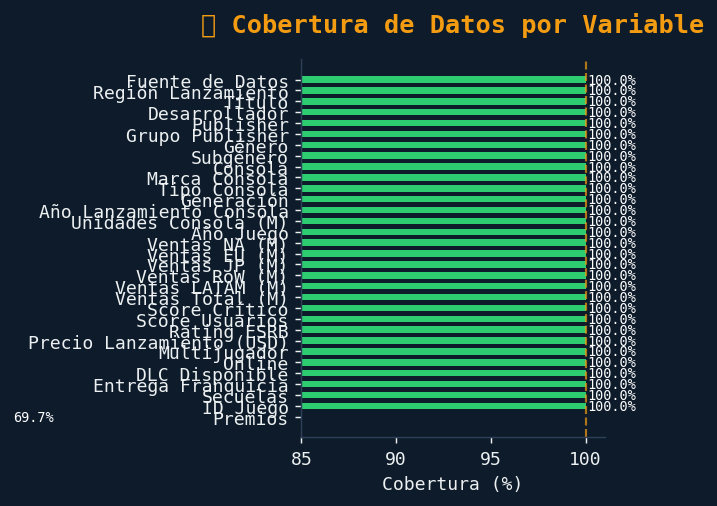

In [9]:
#  Cobertura de datos (nulos) 
nulls    = df.isnull().sum()
coverage = ((len(df) - nulls) / len(df) * 100).round(2)
null_report = pd.DataFrame({'Nulos': nulls, 'Cobertura %': coverage})\
              .sort_values('Cobertura %')

fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ['#2ECC71' if v == 100 else '#E74C3C' for v in null_report['Cobertura %']]
bars = ax.barh(null_report.index, null_report['Cobertura %'],
               color=colors_bar, edgecolor='none', height=0.6)
ax.axvline(100, color=GOLD, linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_xlim(85, 101)
ax.set_xlabel('Cobertura (%)', fontsize=10)
ax.set_title('✅ Cobertura de Datos por Variable',
             fontsize=14, fontweight='bold', color=GOLD, pad=15)
for bar, val in zip(bars, null_report['Cobertura %']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=7.5, color='white')
plt.tight_layout()
plt.show()

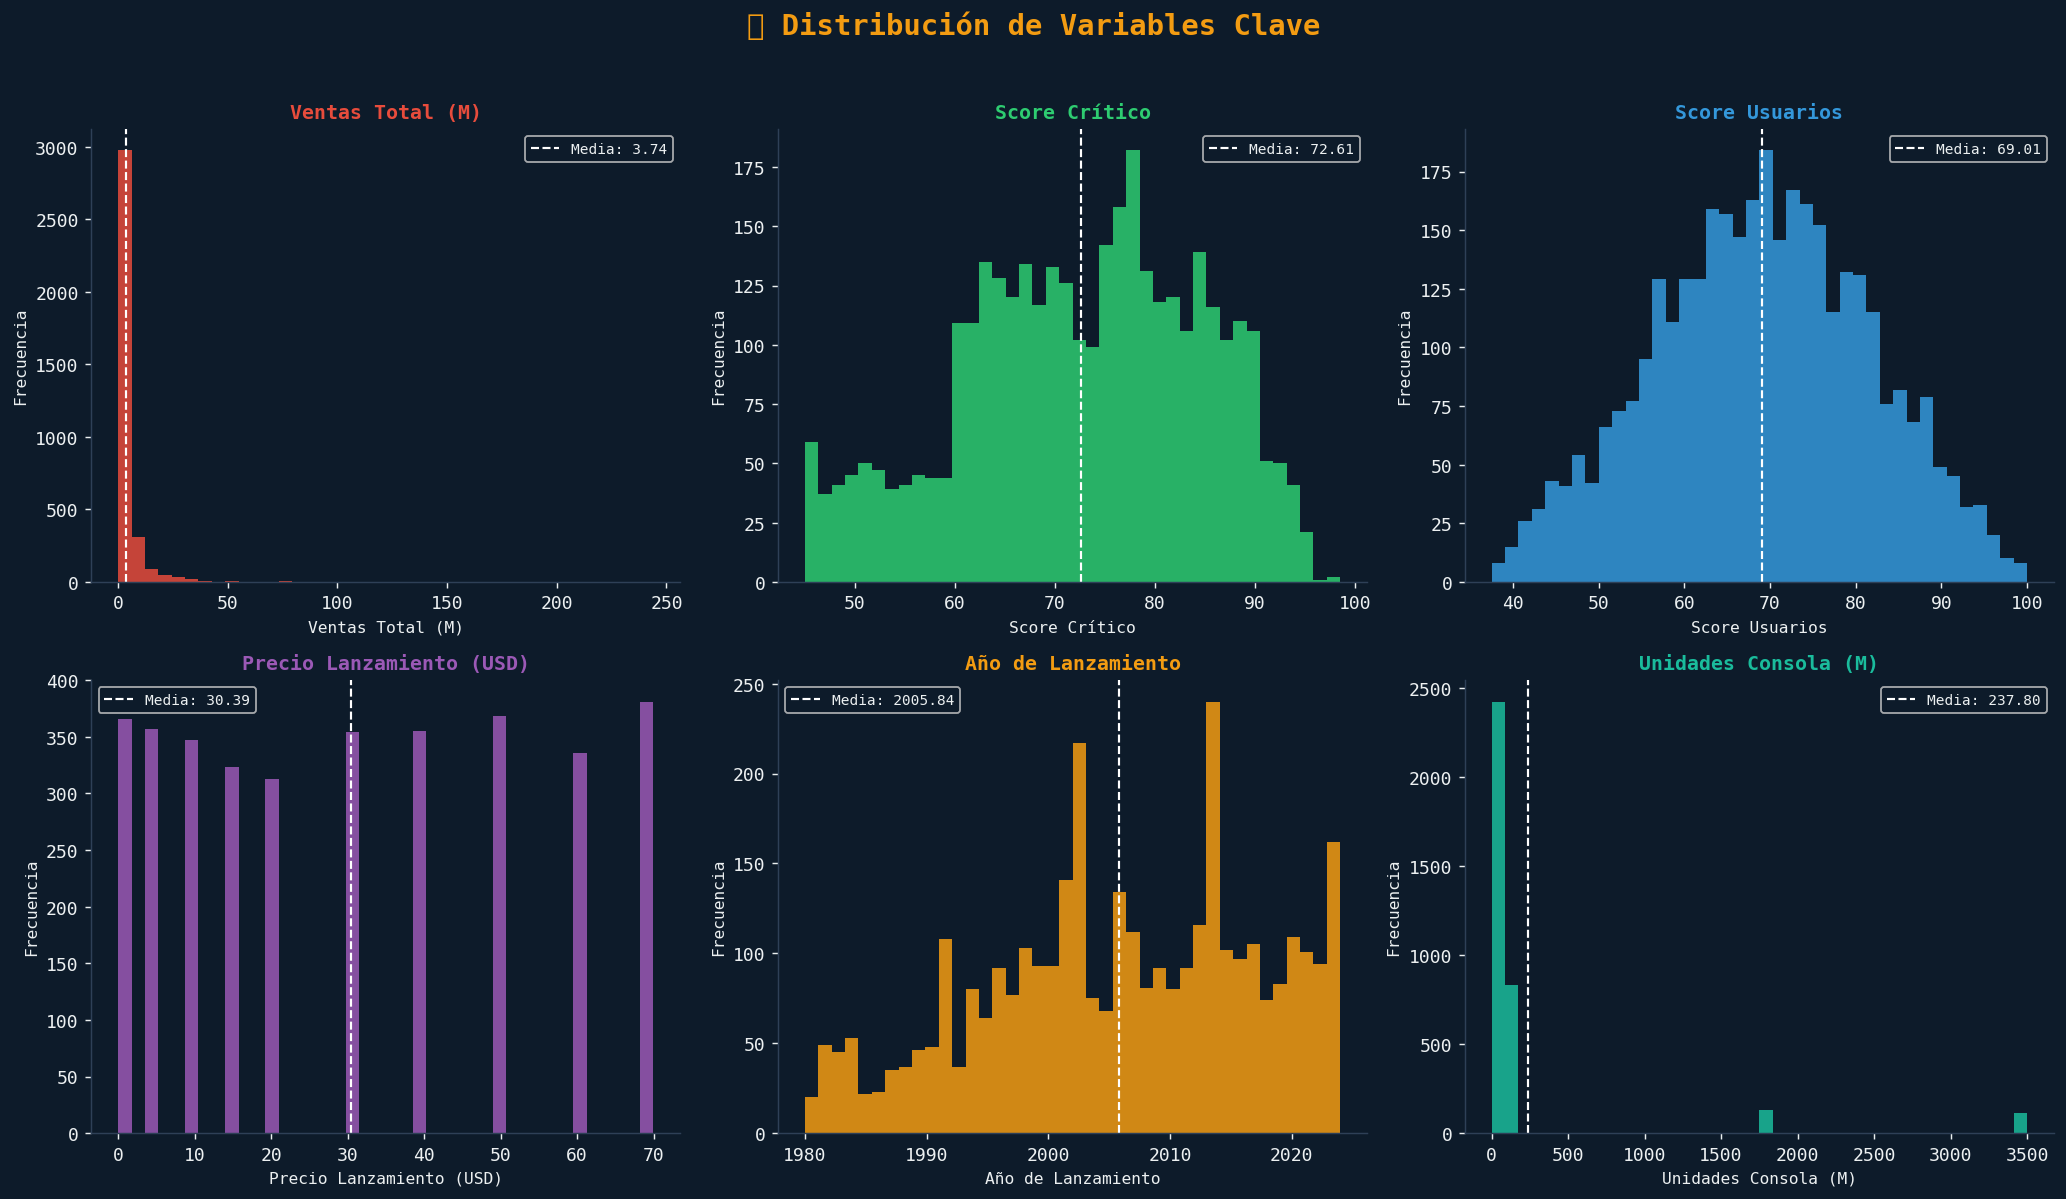

In [10]:
#  Distribución de variables numéricas clave 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('📊 Distribución de Variables Clave',
             fontsize=16, fontweight='bold', color=GOLD, y=1.02)

plot_configs = [
    (COL['ventas_total'],  'Ventas Total (M)',         RED),
    (COL['score_critico'], 'Score Crítico',            '#2ECC71'),
    (COL['score_usuario'], 'Score Usuarios',           BLUE),
    (COL['precio'],        'Precio Lanzamiento (USD)', '#9B59B6'),
    (COL['anio_juego'],    'Año de Lanzamiento',       GOLD),
    (COL['unidades_m'],    'Unidades Consola (M)',     '#1ABC9C'),
]

for ax, (col, label, color) in zip(axes.flat, plot_configs):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.2,
               label=f'Media: {data.mean():.2f}')
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 🏭 Sección 2.— Análisis por Marca de Consola

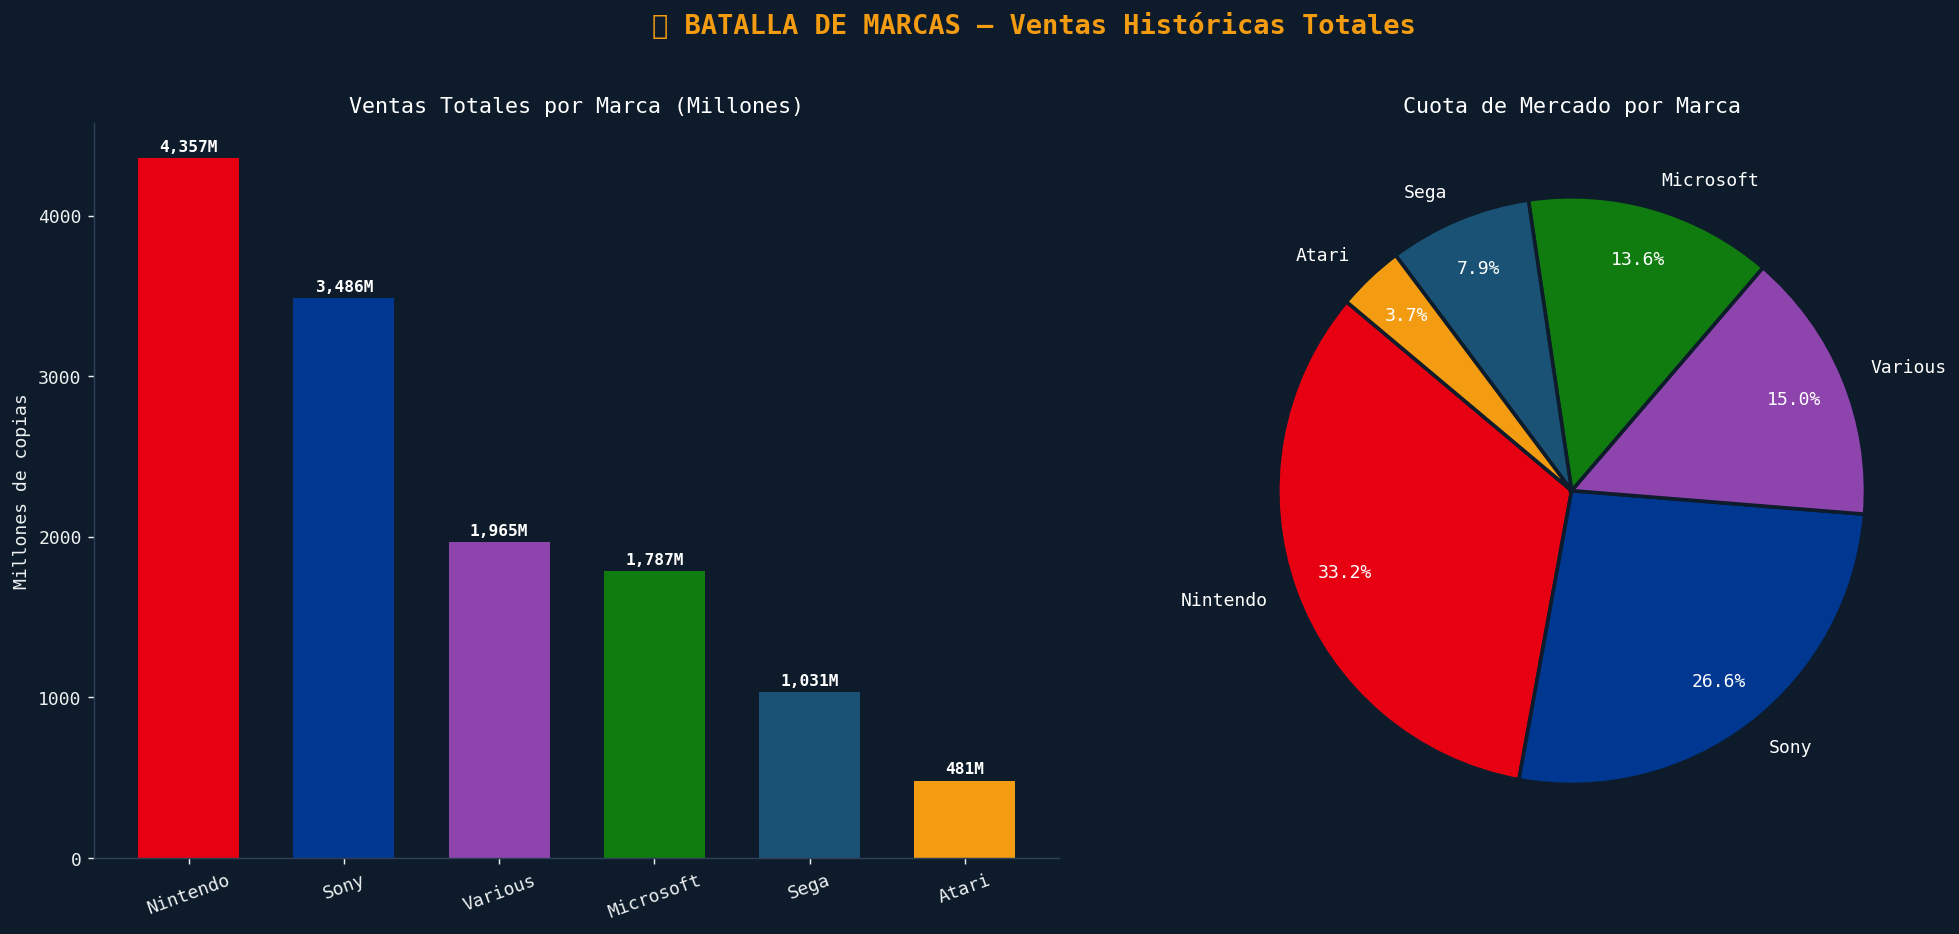

In [11]:
#  Ventas totales por marca 
brand_total = (df.groupby(COL['marca'])[COL['ventas_total']]
               .sum().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('🏭 BATALLA DE MARCAS — Ventas Históricas Totales',
             fontsize=15, fontweight='bold', color=GOLD, y=1.02)

colors_b = [PALETTE_BRANDS.get(b, '#555555') for b in brand_total.index]

# Barras
bars = axes[0].bar(brand_total.index, brand_total.values,
                   color=colors_b, edgecolor='none', width=0.65)
axes[0].set_title('Ventas Totales por Marca (Millones)', fontsize=12, color='white')
axes[0].set_ylabel('Millones de copias', fontsize=10)
for bar, val in zip(bars, brand_total.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + brand_total.max()*0.01,
                 f'{val:,.0f}M', ha='center', fontsize=9,
                 color='white', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Pie
axes[1].pie(brand_total.values, labels=brand_total.index,
            colors=colors_b, autopct='%1.1f%%', startangle=140,
            pctdistance=0.82,
            textprops={'color':'white','fontsize':10},
            wedgeprops={'edgecolor':'#0D1B2A','linewidth':2})
axes[1].set_title('Cuota de Mercado por Marca', fontsize=12, color='white')

plt.tight_layout()
plt.show()

In [12]:
#  Comparativa multidimensional por marca 
brand_multi = df.groupby(COL['marca']).agg(
    ventas_total   = (COL['ventas_total'],  'sum'),
    n_juegos       = (COL['id'],            'count'),
    score_promedio = (COL['score_critico'], 'mean'),
    precio_prom    = (COL['precio'],        'mean'),
    ventas_latam   = (COL['ventas_latam'],  'sum'),
).round(2).sort_values('ventas_total', ascending=False)

brand_multi['ventas_por_juego'] = (brand_multi['ventas_total'] / brand_multi['n_juegos']).round(3)

brand_multi.columns = ['Ventas Total (M)', 'Nº Juegos', 'Score Prom.',
                        'Precio Prom. USD', 'Ventas LATAM (M)', 'Ventas/Juego (M)']
brand_multi.style\
    .background_gradient(cmap='RdYlGn', subset=['Ventas Total (M)','Score Prom.','Ventas/Juego (M)'])\
    .format({
        'Ventas Total (M)':  '{:,.1f} M',
        'Nº Juegos':         '{:,}',
        'Score Prom.':       '{:.1f}',
        'Precio Prom. USD':  '${:.2f}',
        'Ventas LATAM (M)':  '{:.2f} M',
        'Ventas/Juego (M)':  '{:.3f} M',
    })\
    .set_caption("🏭 Métricas Comparativas por Marca de Consola")

,Ventas Total (M),Nº Juegos,Score Prom.,Precio Prom. USD,Ventas LATAM (M),Ventas/Juego (M)
Marca Consola,,,,,,
Nintendo,"4,356.7 M","1,347",72.3,$29.82,159.16 M,3.234 M
Sony,"3,485.8 M",824,73.5,$30.76,122.65 M,4.230 M
Various,"1,964.7 M",243,74.6,$29.56,66.80 M,8.085 M
Microsoft,"1,787.4 M",440,74.1,$29.99,63.42 M,4.062 M
Sega,"1,031.4 M",421,69.9,$32.10,37.85 M,2.450 M
Atari,480.8 M,225,71.3,$31.01,17.63 M,2.137 M


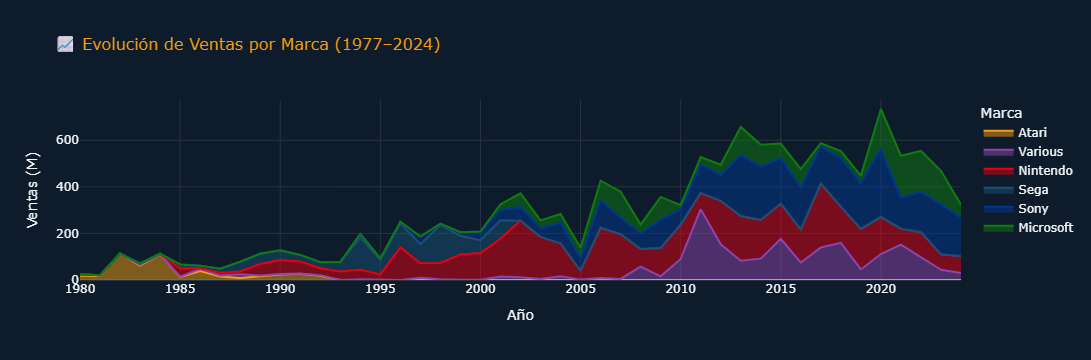

In [13]:
#  Evolución temporal por marca (interactivo Plotly) 
brand_year = df.groupby([COL['anio_juego'], COL['marca']])[COL['ventas_total']].sum().reset_index()
brand_year.columns = ['Año', 'Marca', 'Ventas (M)']

fig = px.area(
    brand_year, x='Año', y='Ventas (M)', color='Marca',
    color_discrete_map=PALETTE_BRANDS,
    title='📈 Evolución de Ventas por Marca (1977–2024)',
    template='plotly_dark',
)
fig.update_layout(
    title_font_size=16, title_font_color=GOLD,
    legend_title='Marca', hovermode='x unified',
    paper_bgcolor='#0D1B2A', plot_bgcolor='#0D1B2A',
)
fig.show()

## 🕹️ Sección 3.— Historia de las Consolas

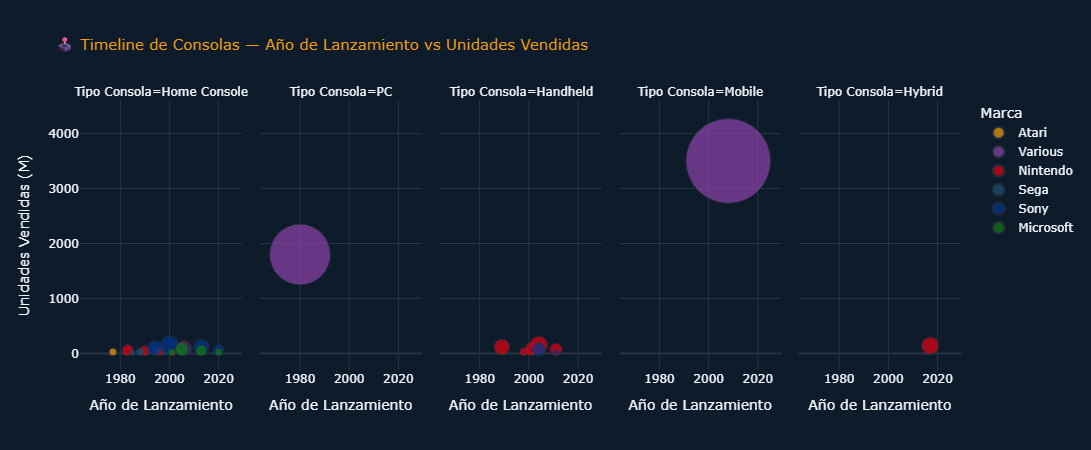

In [14]:
#  Timeline de consolas: Año lanzamiento vs Unidades vendidas
console_info = df[[
    COL['consola'], COL['marca'], COL['tipo_consola'],
    COL['generacion'], COL['anio_consola'], COL['unidades_m']
]].drop_duplicates(COL['consola']).sort_values(COL['anio_consola'])

fig = px.scatter(
    console_info,
    x=COL['anio_consola'],
    y=COL['unidades_m'],
    color=COL['marca'],
    size=COL['unidades_m'],
    size_max=60,
    hover_name=COL['consola'],
    color_discrete_map=PALETTE_BRANDS,
    facet_col=COL['tipo_consola'],
    template='plotly_dark',
    title='🕹️ Timeline de Consolas — Año de Lanzamiento vs Unidades Vendidas',
    labels={
        COL['anio_consola']: 'Año de Lanzamiento',
        COL['unidades_m']:   'Unidades Vendidas (M)',
        COL['marca']:        'Marca',
    }
)
fig.update_layout(
    title_font_size=15, title_font_color=GOLD,
    paper_bgcolor='#0D1B2A', plot_bgcolor='#0D1B2A', height=450,
)
fig.show()


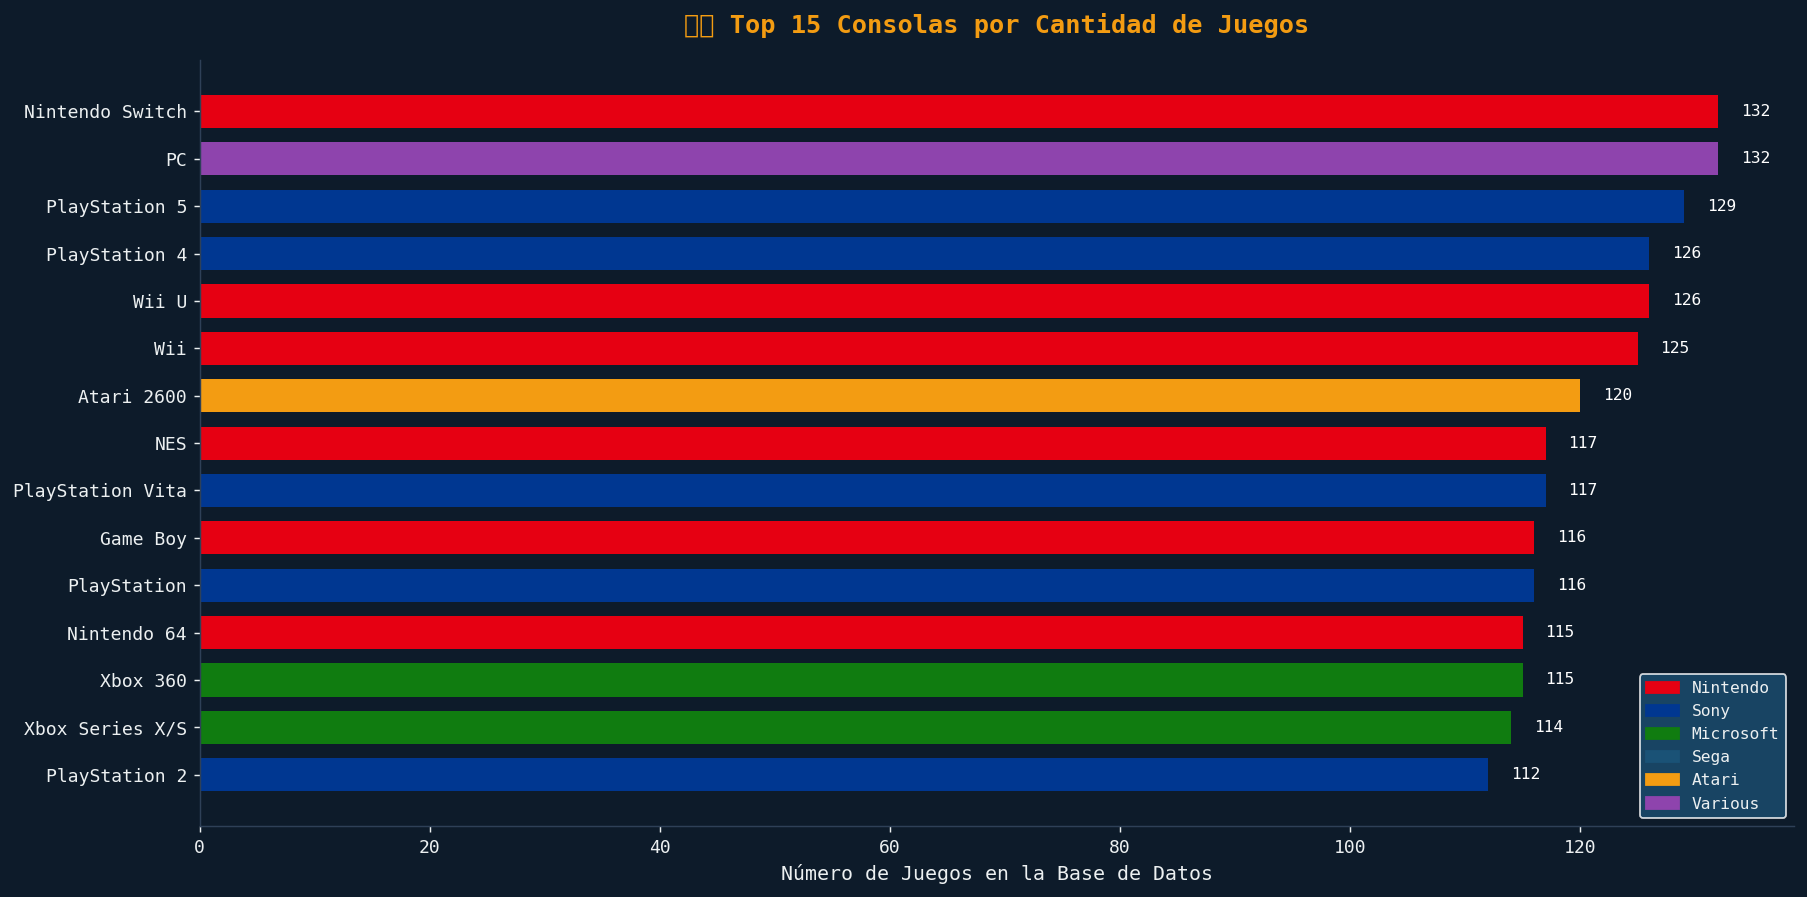

In [15]:
#  Top 15 consolas por número de juegos en el dataset 
top_consoles = (df.groupby([COL['consola'], COL['marca']])
                .agg(n_juegos=(COL['id'],'count'),
                     ventas_prom=(COL['ventas_total'],'mean'))
                .reset_index()
                .nlargest(15, 'n_juegos'))

fig, ax = plt.subplots(figsize=(14, 7))
colors_c = [PALETTE_BRANDS.get(b,'#555') for b in top_consoles[COL['marca']]]
bars = ax.barh(top_consoles[COL['consola']], top_consoles['n_juegos'],
               color=colors_c, edgecolor='none', height=0.7)
ax.invert_yaxis()
for bar, val in zip(bars, top_consoles['n_juegos']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='white')

ax.set_xlabel('Número de Juegos en la Base de Datos', fontsize=11)
ax.set_title('🕹️ Top 15 Consolas por Cantidad de Juegos',
             fontsize=14, fontweight='bold', color=GOLD, pad=15)

legend_patches = [mpatches.Patch(color=v, label=k) for k,v in PALETTE_BRANDS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          facecolor='#1B4F72', edgecolor='white')
plt.tight_layout()
plt.show()


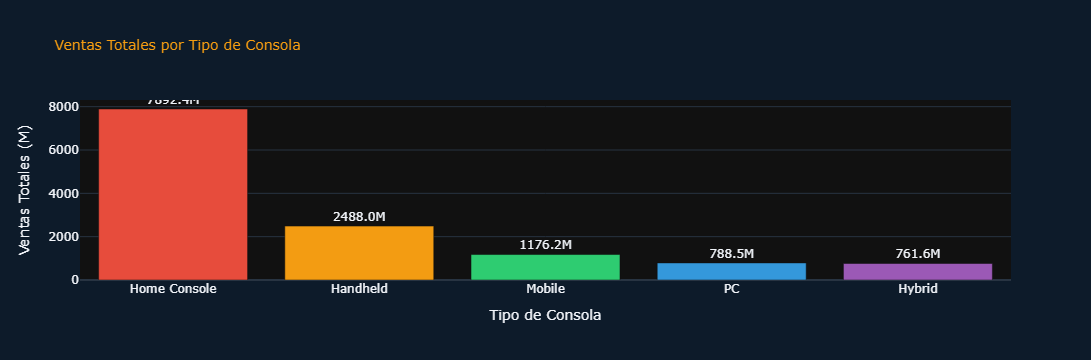


📊 Resumen por Tipo de Consola:
              Ventas Promedio (M)  Ventas Totales (M)  Nº Juegos
Tipo Consola                                                    
Home Console                3.344             7892.41       2360
Handheld                    3.252             2488.03        765
Mobile                     10.596             1176.21        111
PC                          5.974              788.52        132
Hybrid                      5.770              761.65        132


In [16]:
# Ventas promedio por tipo de consola 
type_sales = df.groupby(COL['tipo_consola'])[COL['ventas_total']]\
              .agg(['mean','sum','count']).round(3)
type_sales.columns = ['Ventas Promedio (M)', 'Ventas Totales (M)', 'Nº Juegos']
type_sales = type_sales.sort_values('Ventas Totales (M)', ascending=False)

fig = px.bar(
    type_sales.reset_index(),
    x=COL['tipo_consola'], y='Ventas Totales (M)',
    color=COL['tipo_consola'],
    color_discrete_sequence=PALETTE_MAIN,
    text='Ventas Totales (M)',
    title='Ventas Totales por Tipo de Consola',
    template='plotly_dark',
    labels={COL['tipo_consola']: 'Tipo de Consola'},
)
fig.update_traces(texttemplate='%{text:.1f}M', textposition='outside')
fig.update_layout(showlegend=False, paper_bgcolor='#0D1B2A',
                  title_font_color=GOLD, title_font_size=14)
fig.show()

print("\n📊 Resumen por Tipo de Consola:")
print(type_sales.to_string())


## 🎯 Sección 4.— Análisis por Género

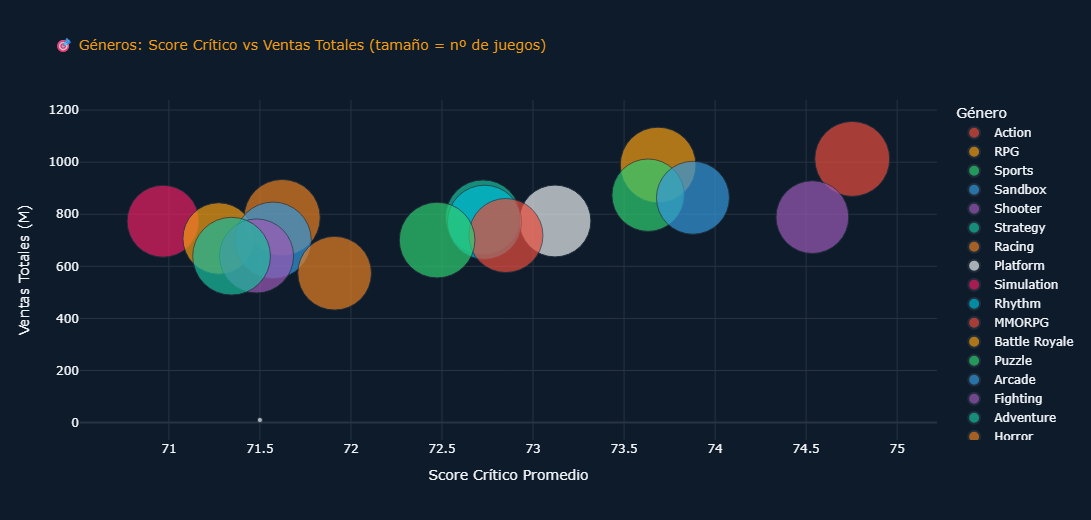

In [17]:
# Ventas y score por género (Bubble chart interactivo) 
genre_stats = df.groupby(COL['genero']).agg(
    ventas_total   = (COL['ventas_total'],  'sum'),
    n_juegos       = (COL['id'],            'count'),
    score_promedio = (COL['score_critico'], 'mean'),
).reset_index().sort_values('ventas_total', ascending=False)

fig = px.scatter(
    genre_stats,
    x='score_promedio', y='ventas_total',
    size='n_juegos', color=COL['genero'],
    hover_name=COL['genero'],
    color_discrete_sequence=PALETTE_MAIN,
    size_max=55,
    template='plotly_dark',
    title='🎯 Géneros: Score Crítico vs Ventas Totales (tamaño = nº de juegos)',
    labels={
        'score_promedio': 'Score Crítico Promedio',
        'ventas_total':   'Ventas Totales (M)',
        COL['genero']:    'Género',
    }
)
fig.update_layout(
    paper_bgcolor='#0D1B2A', plot_bgcolor='#0D1B2A',
    title_font_color=GOLD, title_font_size=14, height=520,
)
fig.show()


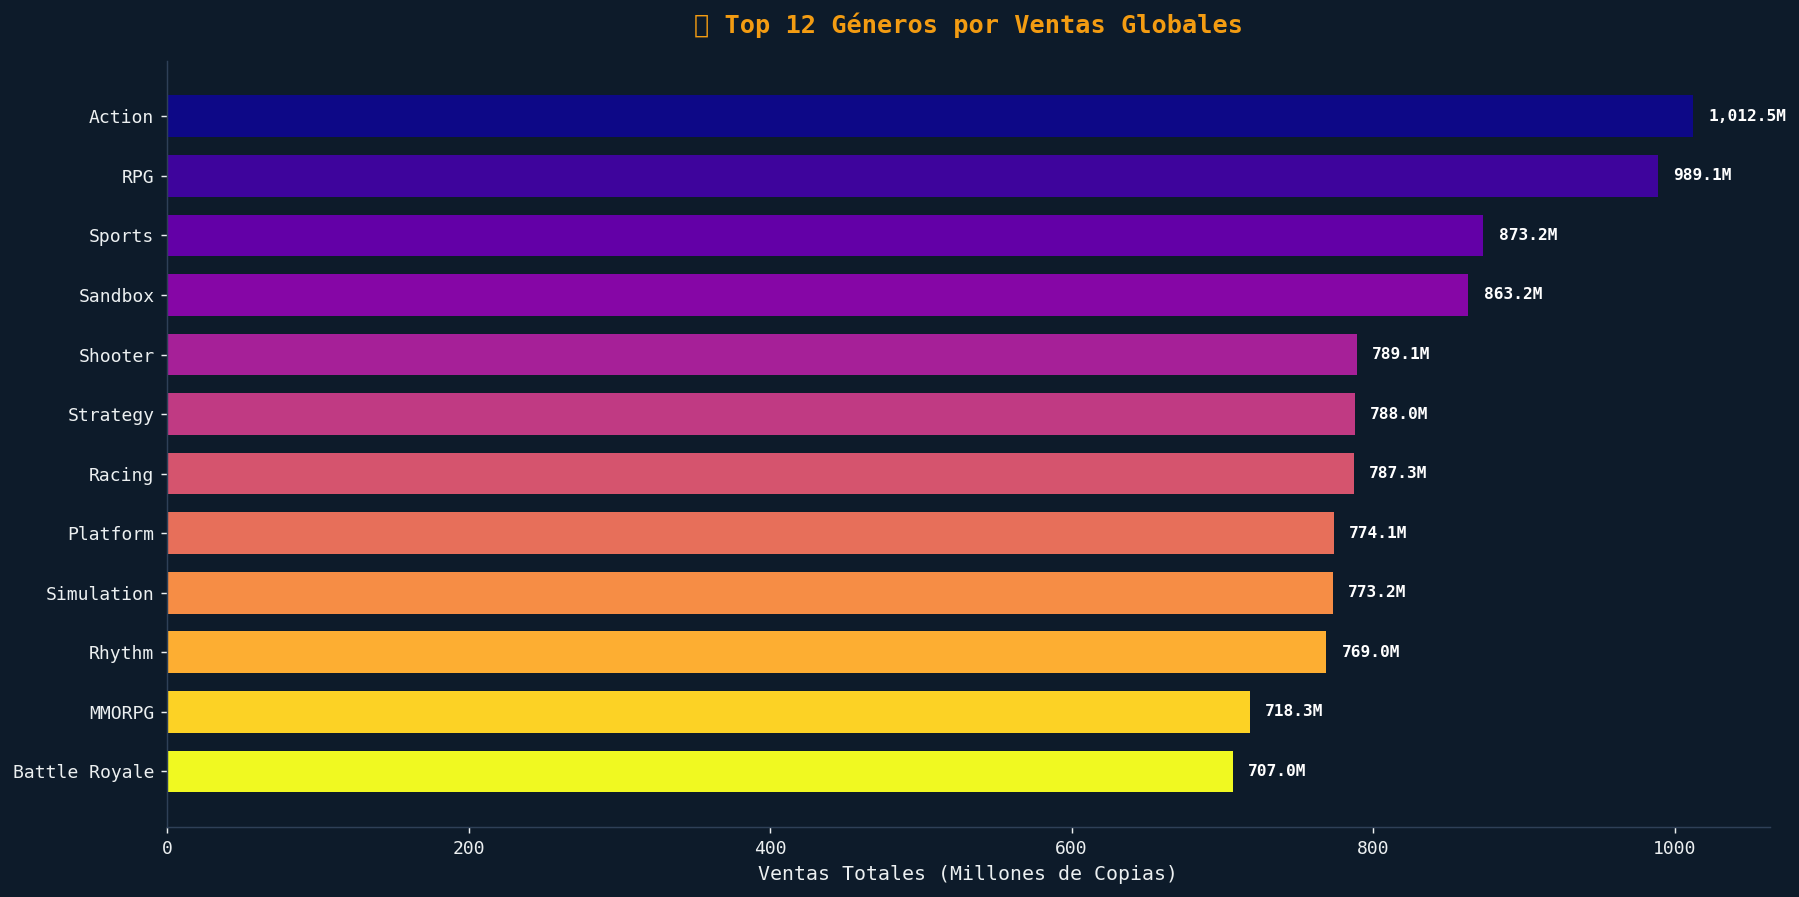

In [18]:
#  Top 12 géneros — barras horizontales
top_genres = genre_stats.nlargest(12, 'ventas_total')

fig, ax = plt.subplots(figsize=(14, 7))
cmap = plt.cm.get_cmap('plasma', len(top_genres))
colors_g = [cmap(i) for i in range(len(top_genres))]

bars = ax.barh(top_genres[COL['genero']], top_genres['ventas_total'],
               color=colors_g, edgecolor='none', height=0.7)
ax.invert_yaxis()
for bar, val in zip(bars, top_genres['ventas_total']):
    ax.text(val + top_genres['ventas_total'].max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.1f}M', va='center', fontsize=9,
            color='white', fontweight='bold')

ax.set_xlabel('Ventas Totales (Millones de Copias)', fontsize=11)
ax.set_title('🎯 Top 12 Géneros por Ventas Globales',
             fontsize=14, fontweight='bold', color=GOLD, pad=15)
plt.tight_layout()
plt.show()

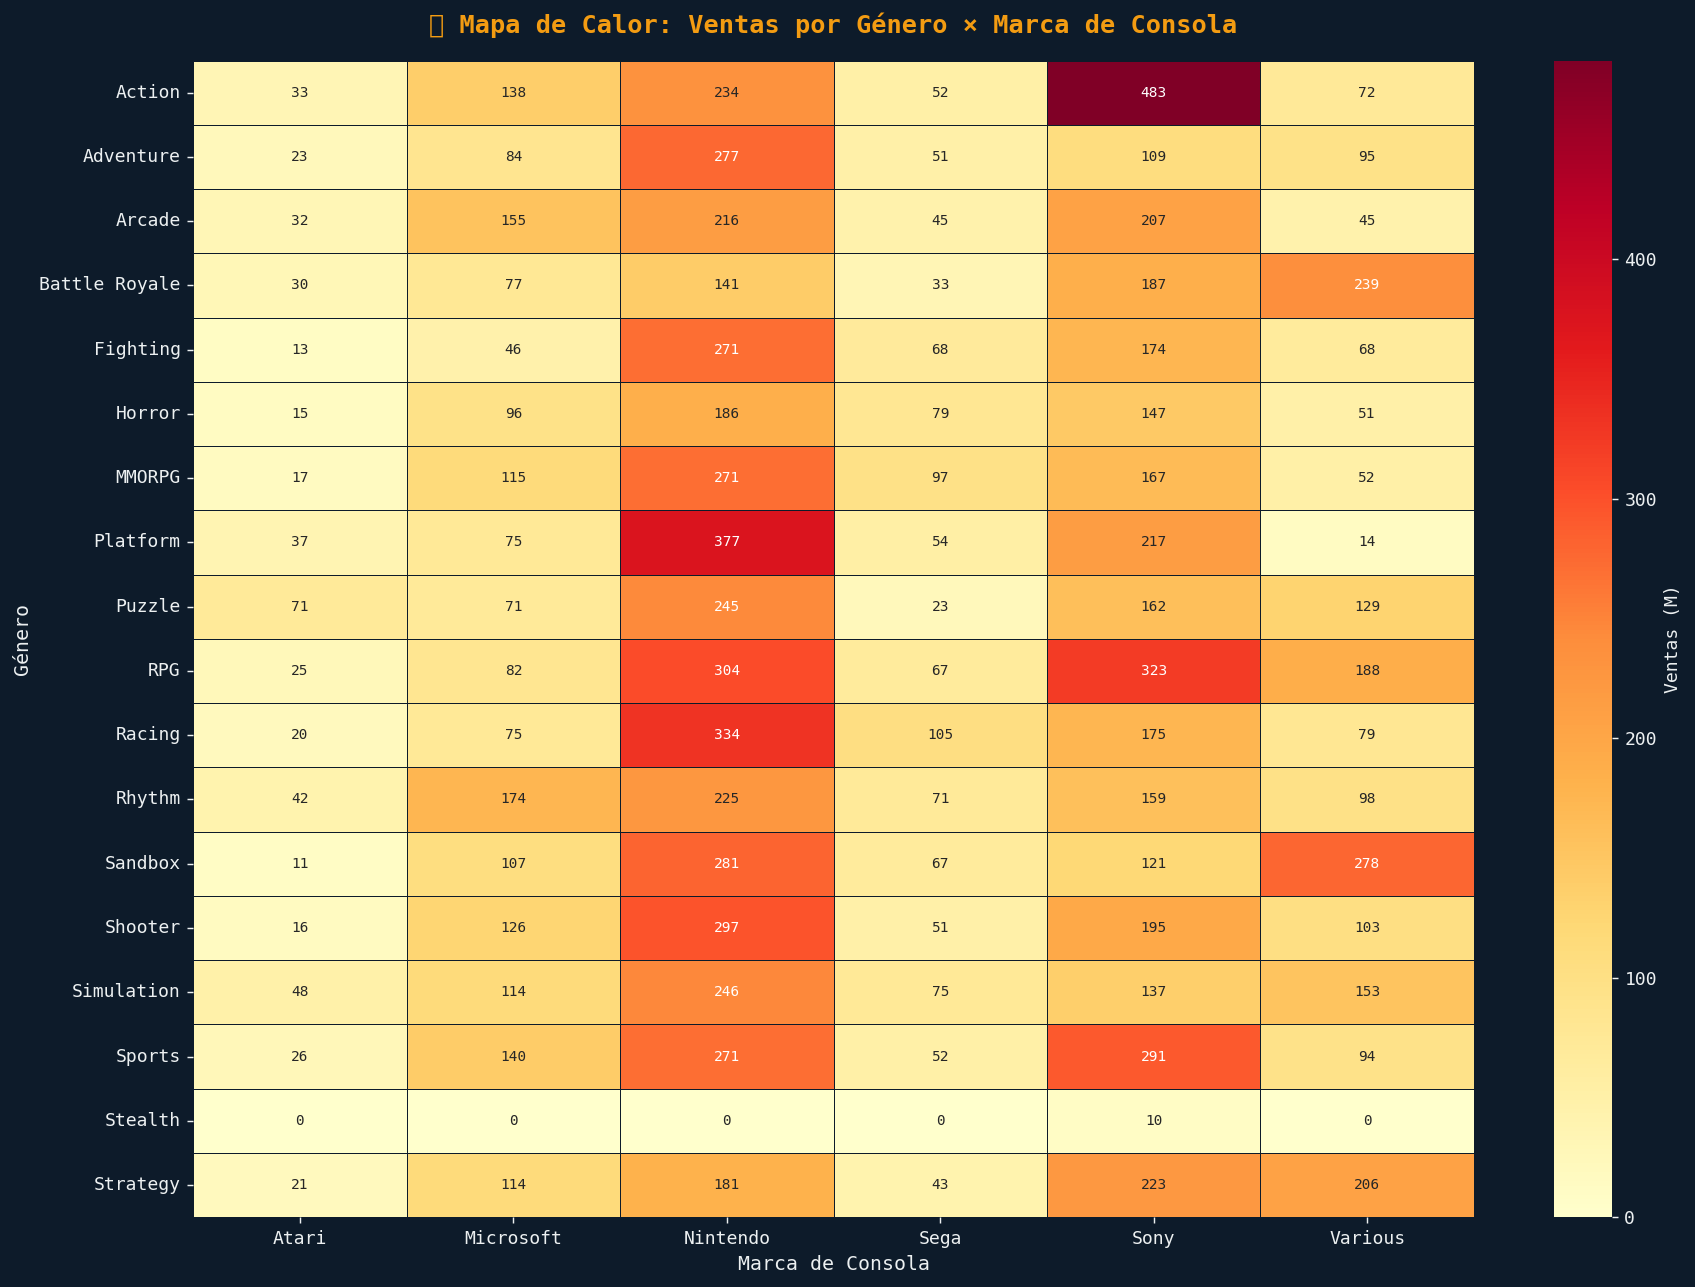

In [19]:
#  Heatmap: Ventas por Género × Marca 
pivot_gm = df.pivot_table(
    index=COL['genero'], columns=COL['marca'],
    values=COL['ventas_total'], aggfunc='sum', fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot_gm, annot=True, fmt='.0f', linewidths=0.5,
    cmap='YlOrRd', ax=ax, linecolor='#0D1B2A',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Ventas (M)'}
)
ax.set_title('🔥 Mapa de Calor: Ventas por Género × Marca de Consola',
             fontsize=14, fontweight='bold', color=GOLD, pad=15)
ax.set_xlabel('Marca de Consola', fontsize=11)
ax.set_ylabel('Género', fontsize=11)
plt.tight_layout()
plt.show()

## 📅 Sección 5.— Evolución Temporal (1977–2024)

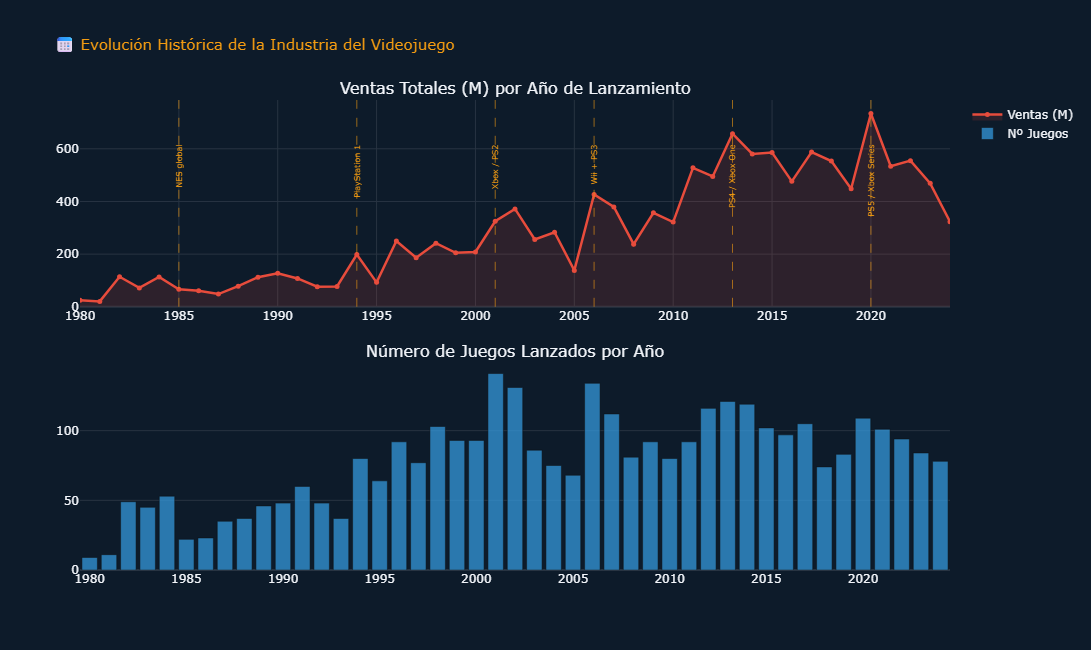

In [20]:
#  Serie de tiempo con hitos históricos 
year_data = df.groupby(COL['anio_juego']).agg(
    ventas = (COL['ventas_total'], 'sum'),
    juegos = (COL['id'],          'count'),
).reset_index().sort_values(COL['anio_juego'])

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        'Ventas Totales (M) por Año de Lanzamiento',
        'Número de Juegos Lanzados por Año'
    ),
    vertical_spacing=0.12,
)

fig.add_trace(go.Scatter(
    x=year_data[COL['anio_juego']], y=year_data['ventas'],
    mode='lines+markers', name='Ventas (M)',
    line=dict(color=RED, width=2.5),
    marker=dict(size=5, color=RED),
    fill='tozeroy', fillcolor='rgba(231,76,60,0.15)',
), row=1, col=1)

fig.add_trace(go.Bar(
    x=year_data[COL['anio_juego']], y=year_data['juegos'],
    name='Nº Juegos', marker_color='rgba(52,152,219,0.75)',
), row=2, col=1)

# Hitos históricos
milestones = {
    1985: 'NES global',
    1994: 'PlayStation 1',
    2001: 'Xbox / PS2',
    2006: 'Wii + PS3',
    2013: 'PS4 / Xbox One',
    2020: 'PS5 / Xbox Series',
}
for year, label in milestones.items():
    fig.add_vline(x=year, line_dash='dash', line_color=GOLD,
                  line_width=1, opacity=0.6, row=1, col=1)
    fig.add_annotation(
        x=year, y=year_data['ventas'].max() * 0.85,
        text=label, showarrow=False,
        font=dict(color=GOLD, size=8),
        textangle=-90, row=1, col=1, yanchor='top'
    )

fig.update_layout(
    template='plotly_dark', height=650,
    title_text='📅 Evolución Histórica de la Industria del Videojuego',
    title_font_size=15, title_font_color=GOLD,
    paper_bgcolor='#0D1B2A', plot_bgcolor='#0D1B2A',
    showlegend=True, hovermode='x unified',
)
fig.show()

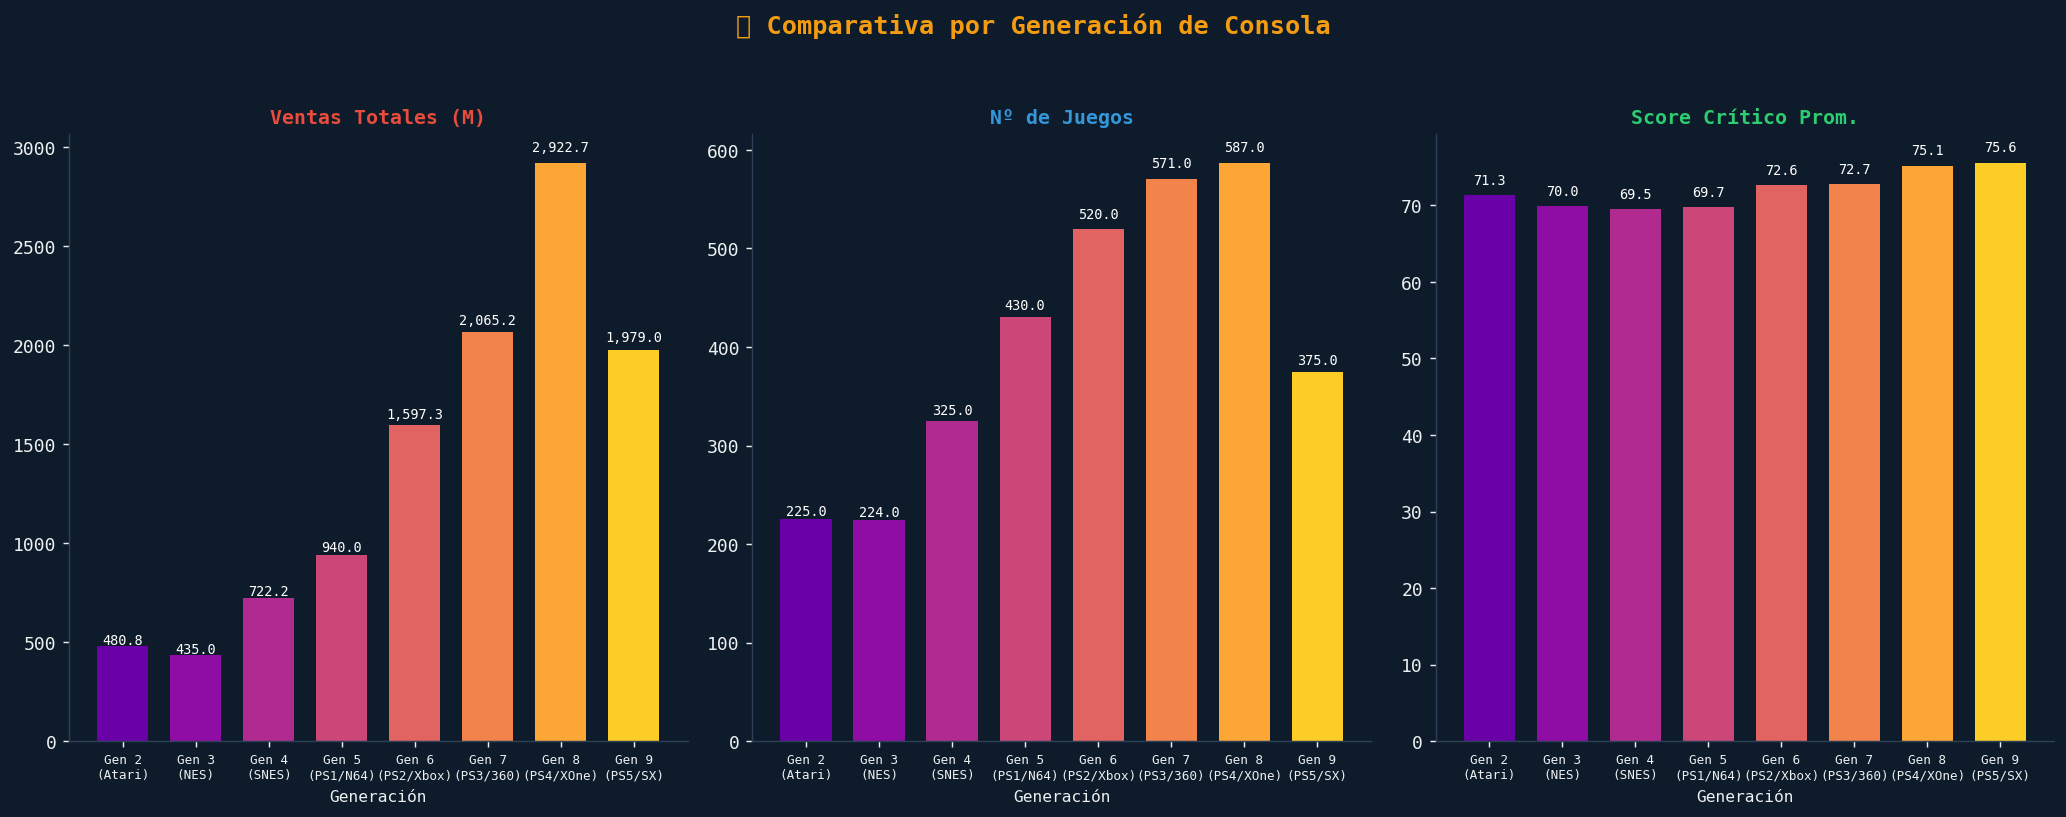

In [21]:
# Comparativa por generación de consola 
gen_data = df.groupby(COL['generacion']).agg(
    ventas  = (COL['ventas_total'],  'sum'),
    juegos  = (COL['id'],            'count'),
    score   = (COL['score_critico'], 'mean'),
).reset_index()
gen_data = gen_data[gen_data[COL['generacion']] > 0]

gen_labels = {
    2:'Gen 2\n(Atari)', 3:'Gen 3\n(NES)', 4:'Gen 4\n(SNES)',
    5:'Gen 5\n(PS1/N64)', 6:'Gen 6\n(PS2/Xbox)',
    7:'Gen 7\n(PS3/360)', 8:'Gen 8\n(PS4/XOne)',
    9:'Gen 9\n(PS5/SX)',
}
gen_data['label'] = gen_data[COL['generacion']].map(gen_labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('🎮 Comparativa por Generación de Consola',
             fontsize=14, fontweight='bold', color=GOLD, y=1.04)

cmap_gen = plt.cm.plasma(np.linspace(0.2, 0.9, len(gen_data)))
metrics = [('ventas','Ventas Totales (M)',RED),
           ('juegos','Nº de Juegos',BLUE),
           ('score', 'Score Crítico Prom.','#2ECC71')]

for ax, (col, label, color) in zip(axes, metrics):
    bars_g = ax.bar(gen_data['label'], gen_data[col],
                    color=cmap_gen, edgecolor='none', width=0.7)
    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Generación', fontsize=9)
    ax.tick_params(axis='x', labelsize=7)
    for bar, val in zip(bars_g, gen_data[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.02,
                f'{val:,.1f}', ha='center', fontsize=7.5, color='white')

plt.tight_layout()
plt.show()


## 🌎 Sección 6.— Análisis Regional de Ventas

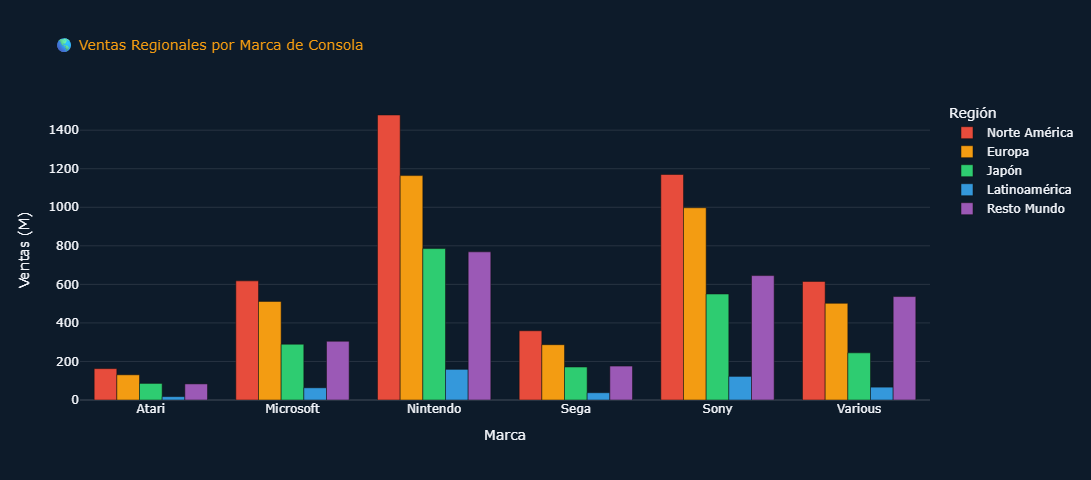

In [22]:
#  Ventas por región agrupadas por marca 
region_brand = df.groupby(COL['marca'])[[
    COL['ventas_na'], COL['ventas_eu'], COL['ventas_jp'],
    COL['ventas_latam'], COL['ventas_row']
]].sum()
region_brand.columns = ['Norte América','Europa','Japón','Latinoamérica','Resto Mundo']

fig = px.bar(
    region_brand.reset_index().melt(
        id_vars=COL['marca'], var_name='Región', value_name='Ventas (M)'
    ),
    x=COL['marca'], y='Ventas (M)', color='Región',
    barmode='group',
    color_discrete_sequence=PALETTE_MAIN,
    title='🌎 Ventas Regionales por Marca de Consola',
    labels={COL['marca']: 'Marca'},
    template='plotly_dark',
)
fig.update_layout(
    paper_bgcolor='#0D1B2A', plot_bgcolor='#0D1B2A',
    title_font_color=GOLD, title_font_size=14, height=480,
)
fig.show()

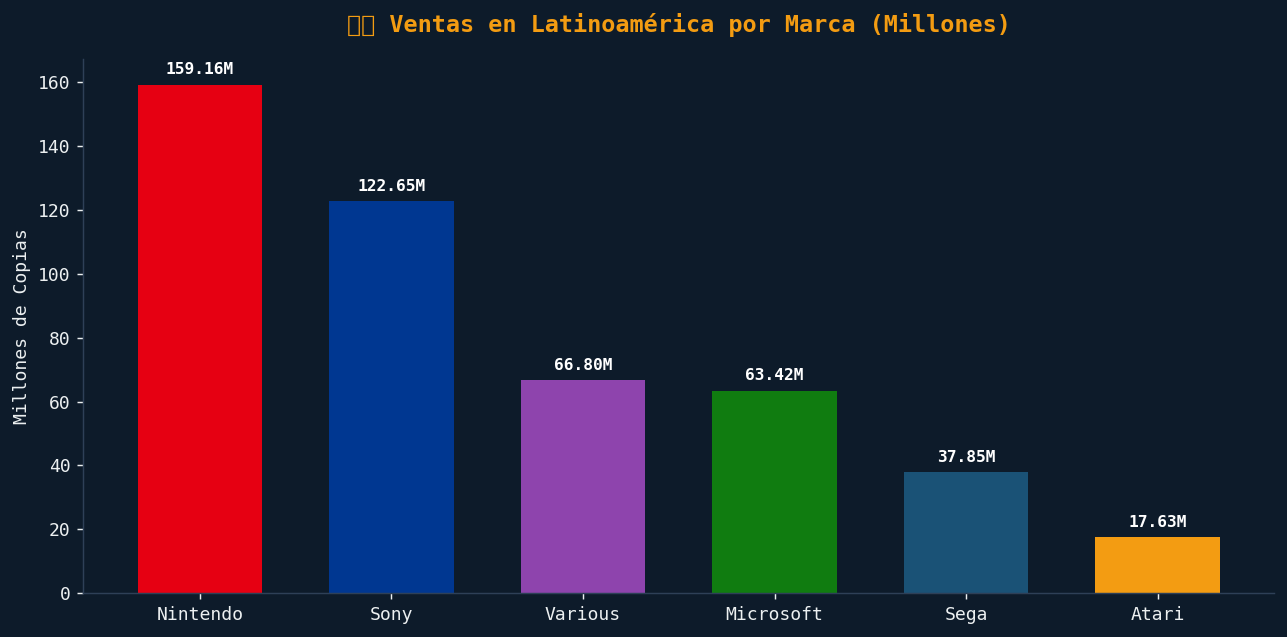


🌎 Total ventas LATAM en dataset : 467.51 millones de copias
   Porcentaje del mercado global  : 3.57%


In [23]:
# LATAM Focus
latam_data = df.groupby(COL['marca'])[COL['ventas_latam']].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_l = [PALETTE_BRANDS.get(b,'#555') for b in latam_data.index]
bars = ax.bar(latam_data.index, latam_data.values,
              color=colors_l, edgecolor='none', width=0.65)
ax.set_title('🇨🇱 Ventas en Latinoamérica por Marca (Millones)',
             fontsize=13, fontweight='bold', color=GOLD, pad=15)
ax.set_ylabel('Millones de Copias', fontsize=10)

for bar, val in zip(bars, latam_data.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + latam_data.max() * 0.02,
            f'{val:.2f}M', ha='center', fontsize=9,
            color='white', fontweight='bold')
plt.tight_layout()
plt.show()

total_latam  = df[COL['ventas_latam']].sum()
total_global = df[COL['ventas_total']].sum()
print(f"\n🌎 Total ventas LATAM en dataset : {total_latam:,.2f} millones de copias")
print(f"   Porcentaje del mercado global  : {100*total_latam/total_global:.2f}%")


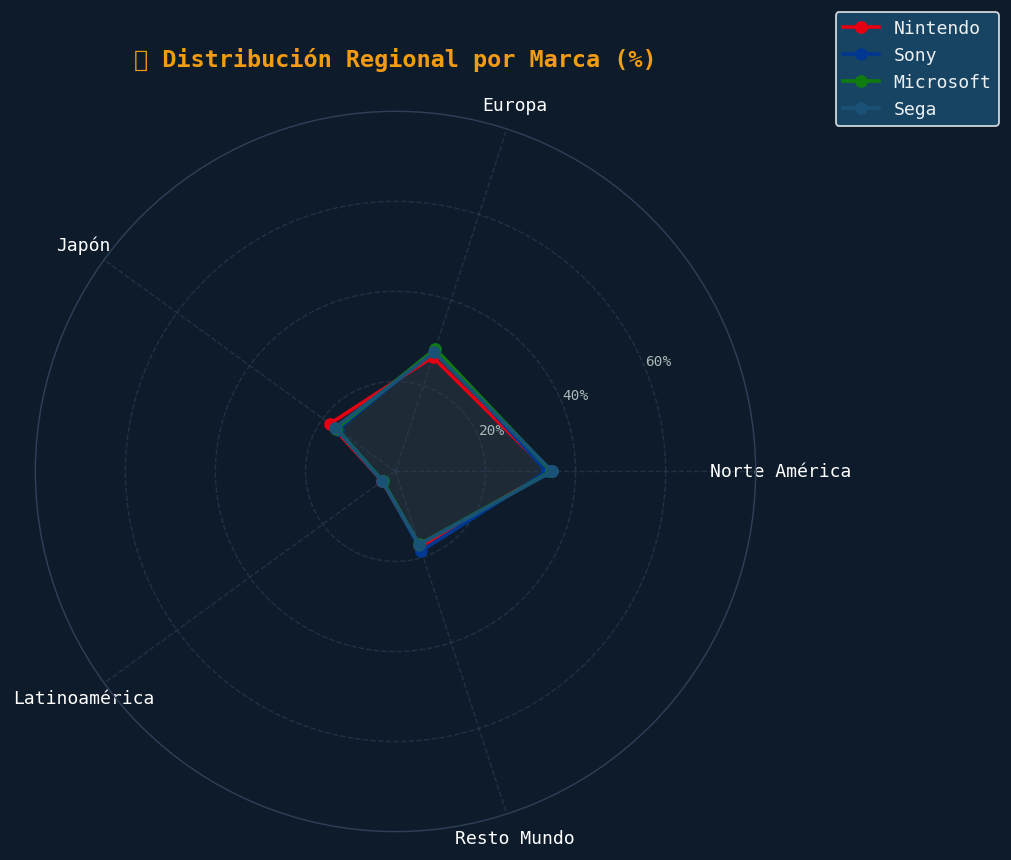

In [24]:
# Radar chart: Distribución regional por marca 
brands_radar = ['Nintendo','Sony','Microsoft','Sega']
region_cols_list = [COL['ventas_na'], COL['ventas_eu'], COL['ventas_jp'],
                    COL['ventas_latam'], COL['ventas_row']]
region_names     = ['Norte América','Europa','Japón','Latinoamérica','Resto Mundo']

radar_data = {}
for brand in brands_radar:
    sub   = df[df[COL['marca']] == brand][region_cols_list].sum()
    total = sub.sum()
    if total > 0:
        radar_data[brand] = (sub / total * 100).values.tolist()

angles = np.linspace(0, 2*np.pi, len(region_names), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#0D1B2A')
fig.patch.set_facecolor('#0D1B2A')

for brand, values in radar_data.items():
    vals  = values + values[:1]
    color = PALETTE_BRANDS.get(brand,'#555')
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=brand)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(region_names, fontsize=10, color='white')
ax.set_yticks([20, 40, 60])
ax.set_yticklabels(['20%','40%','60%'], fontsize=8, color='#AAB7B8')
ax.set_ylim(0, 80)
ax.grid(color='#2E4057', linestyle='--', alpha=0.6)
ax.spines['polar'].set_color('#2E4057')
ax.set_title('🌎 Distribución Regional por Marca (%)',
             fontsize=13, fontweight='bold', color=GOLD, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          facecolor='#1B4F72', edgecolor='white', fontsize=10)
plt.tight_layout()
plt.show()


## ⭐ Sección 7.— Calidad vs Ventas: ¿Los mejores juegos son los más vendidos?

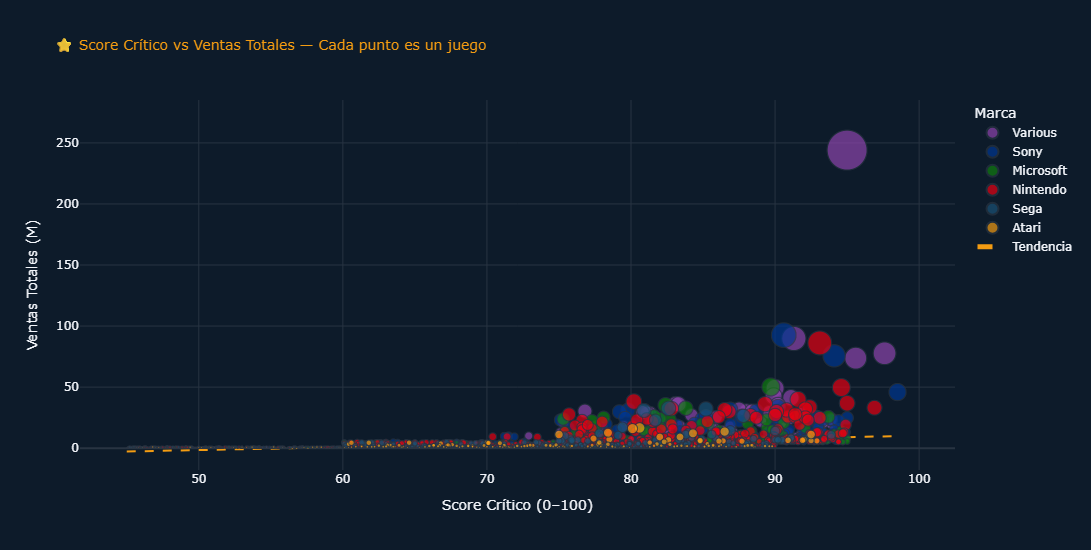

In [25]:
# Scatter interactivo Score vs Ventas
df_plot = df[df[COL['ventas_total']] > 0.1].copy()

fig = px.scatter(
    df_plot,
    x=COL['score_critico'], y=COL['ventas_total'],
    color=COL['marca'],
    size=COL['ventas_total'],
    size_max=40,
    hover_name=COL['titulo'],
    hover_data={
        COL['anio_juego']:    True,
        COL['genero']:        True,
        COL['score_critico']: ':.1f',
        COL['ventas_total']:  ':.2f',
    },
    color_discrete_map=PALETTE_BRANDS,
    opacity=0.7,
    template='plotly_dark',
    title='⭐ Score Crítico vs Ventas Totales — Cada punto es un juego',
    labels={
        COL['score_critico']: 'Score Crítico (0–100)',
        COL['ventas_total']:  'Ventas Totales (M)',
        COL['marca']:         'Marca',
    }
)

# Línea de tendencia
df_valid = df_plot.dropna(subset=[COL['score_critico'], COL['ventas_total']])
z  = np.polyfit(df_valid[COL['score_critico']], df_valid[COL['ventas_total']], 1)
p  = np.poly1d(z)
x_line = np.linspace(df_valid[COL['score_critico']].min(),
                     df_valid[COL['score_critico']].max(), 100)
fig.add_trace(go.Scatter(
    x=x_line, y=p(x_line), mode='lines',
    name='Tendencia', line=dict(color=GOLD, width=2, dash='dash')
))

fig.update_layout(
    paper_bgcolor='#0D1B2A', plot_bgcolor='#0D1B2A',
    title_font_color=GOLD, title_font_size=14, height=550,
)
fig.show()


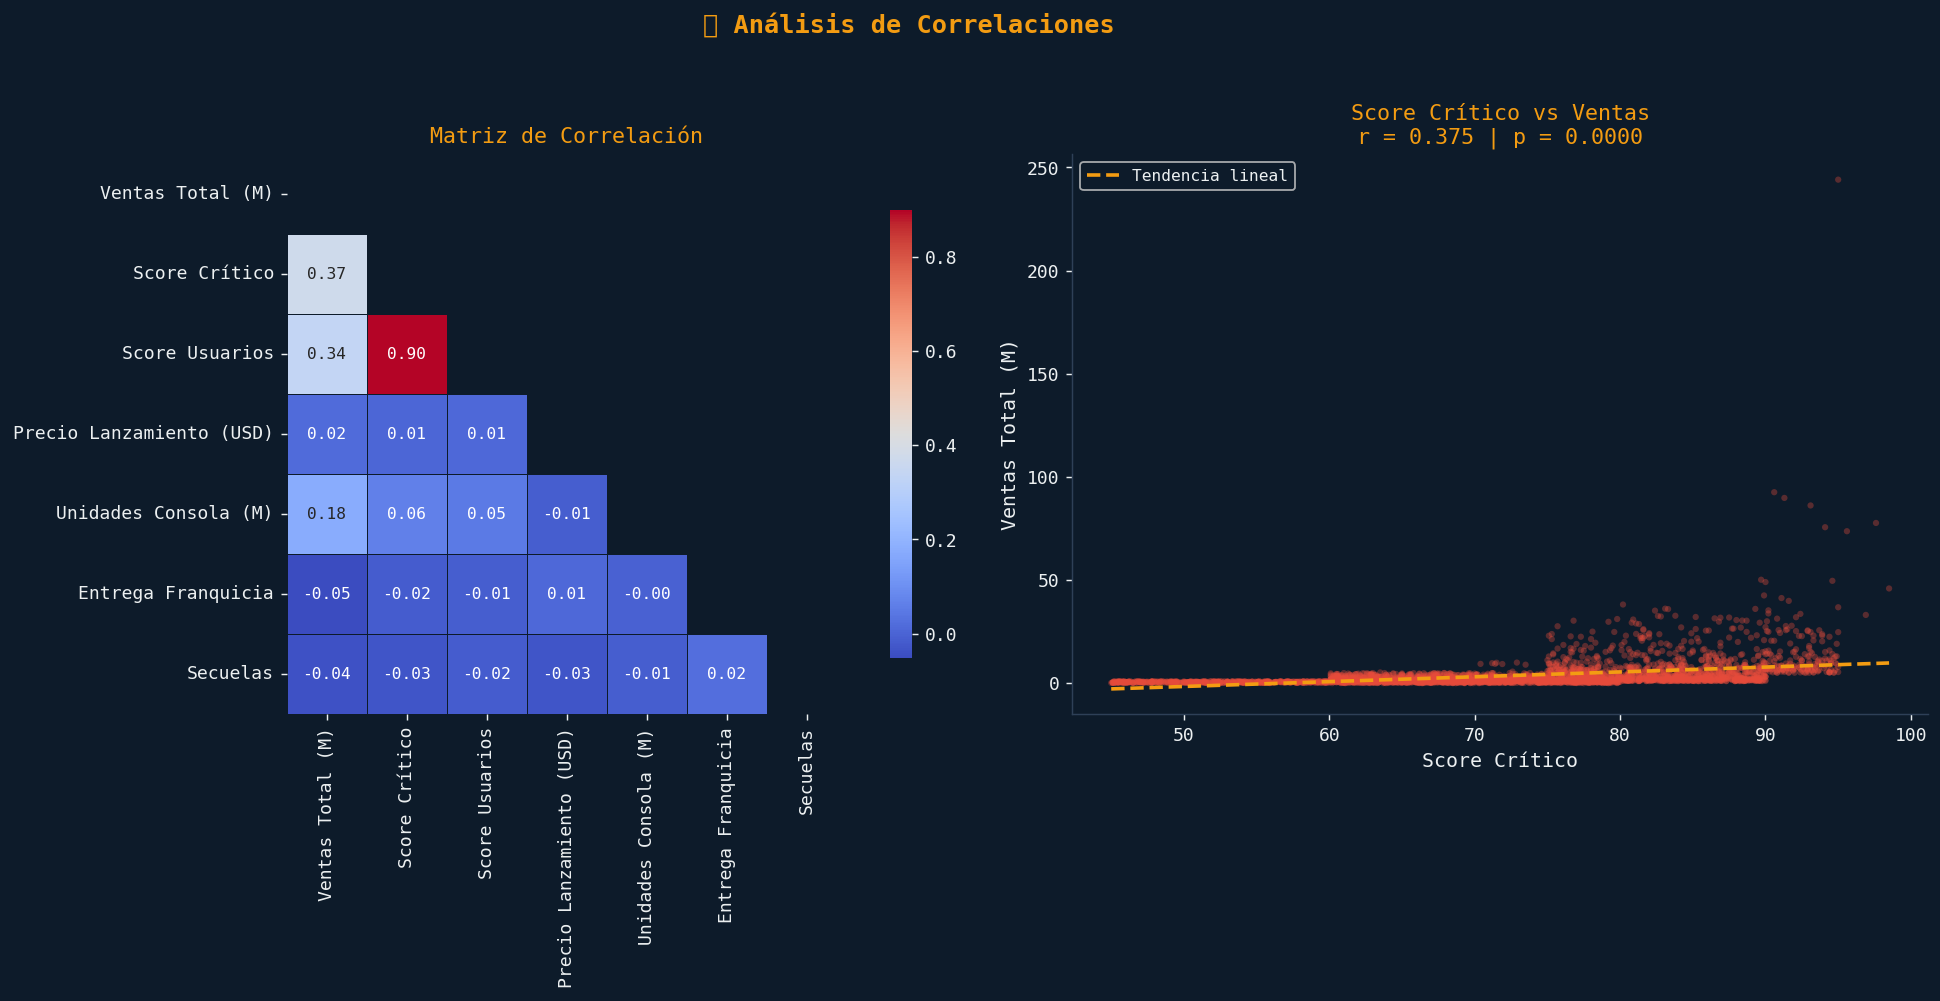


📊 Correlación de variables con Ventas Total:
  Score Crítico                       +0.375  ███████████
  Score Usuarios                      +0.337  ██████████
  Unidades Consola (M)                +0.178  █████
  Entrega Franquicia                  -0.053  █
  Secuelas                            -0.040  █
  Precio Lanzamiento (USD)            +0.015  


In [26]:
# Análisis de correlaciones 
from scipy import stats as scipy_stats

cols_corr = [
    COL['ventas_total'], COL['score_critico'], COL['score_usuario'],
    COL['precio'], COL['unidades_m'], COL['entrega'], COL['secuelas']
]
df_corr    = df[cols_corr].dropna()
corr_matrix = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('⭐ Análisis de Correlaciones', fontsize=14,
             fontweight='bold', color=GOLD, y=1.03)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[0], linewidths=0.5,
            linecolor='#0D1B2A', square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
axes[0].set_title('Matriz de Correlación', fontsize=12, color=GOLD)

r_val, p_val = scipy_stats.pearsonr(df_corr[COL['score_critico']], df_corr[COL['ventas_total']])
axes[1].scatter(df_corr[COL['score_critico']], df_corr[COL['ventas_total']],
                alpha=0.35, color=RED, s=12, edgecolors='none')
m, b  = np.polyfit(df_corr[COL['score_critico']], df_corr[COL['ventas_total']], 1)
x_vals = np.linspace(df_corr[COL['score_critico']].min(),
                      df_corr[COL['score_critico']].max(), 100)
axes[1].plot(x_vals, m*x_vals + b, color=GOLD, linewidth=2,
             linestyle='--', label='Tendencia lineal')
axes[1].set_xlabel(COL['score_critico'],  fontsize=11)
axes[1].set_ylabel(COL['ventas_total'],   fontsize=11)
axes[1].set_title(f'Score Crítico vs Ventas\nr = {r_val:.3f} | p = {p_val:.4f}',
                   fontsize=12, color=GOLD)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

corr_target = corr_matrix[COL['ventas_total']].drop(COL['ventas_total'])\
              .sort_values(key=abs, ascending=False)
print("\n📊 Correlación de variables con Ventas Total:")
for var, val in corr_target.items():
    bar_str = '█' * int(abs(val) * 30)
    sign    = '+' if val > 0 else '-'
    print(f"  {var:<35} {sign}{abs(val):.3f}  {bar_str}")

## 🏆 Sección 8.— Rankings y Top Listas

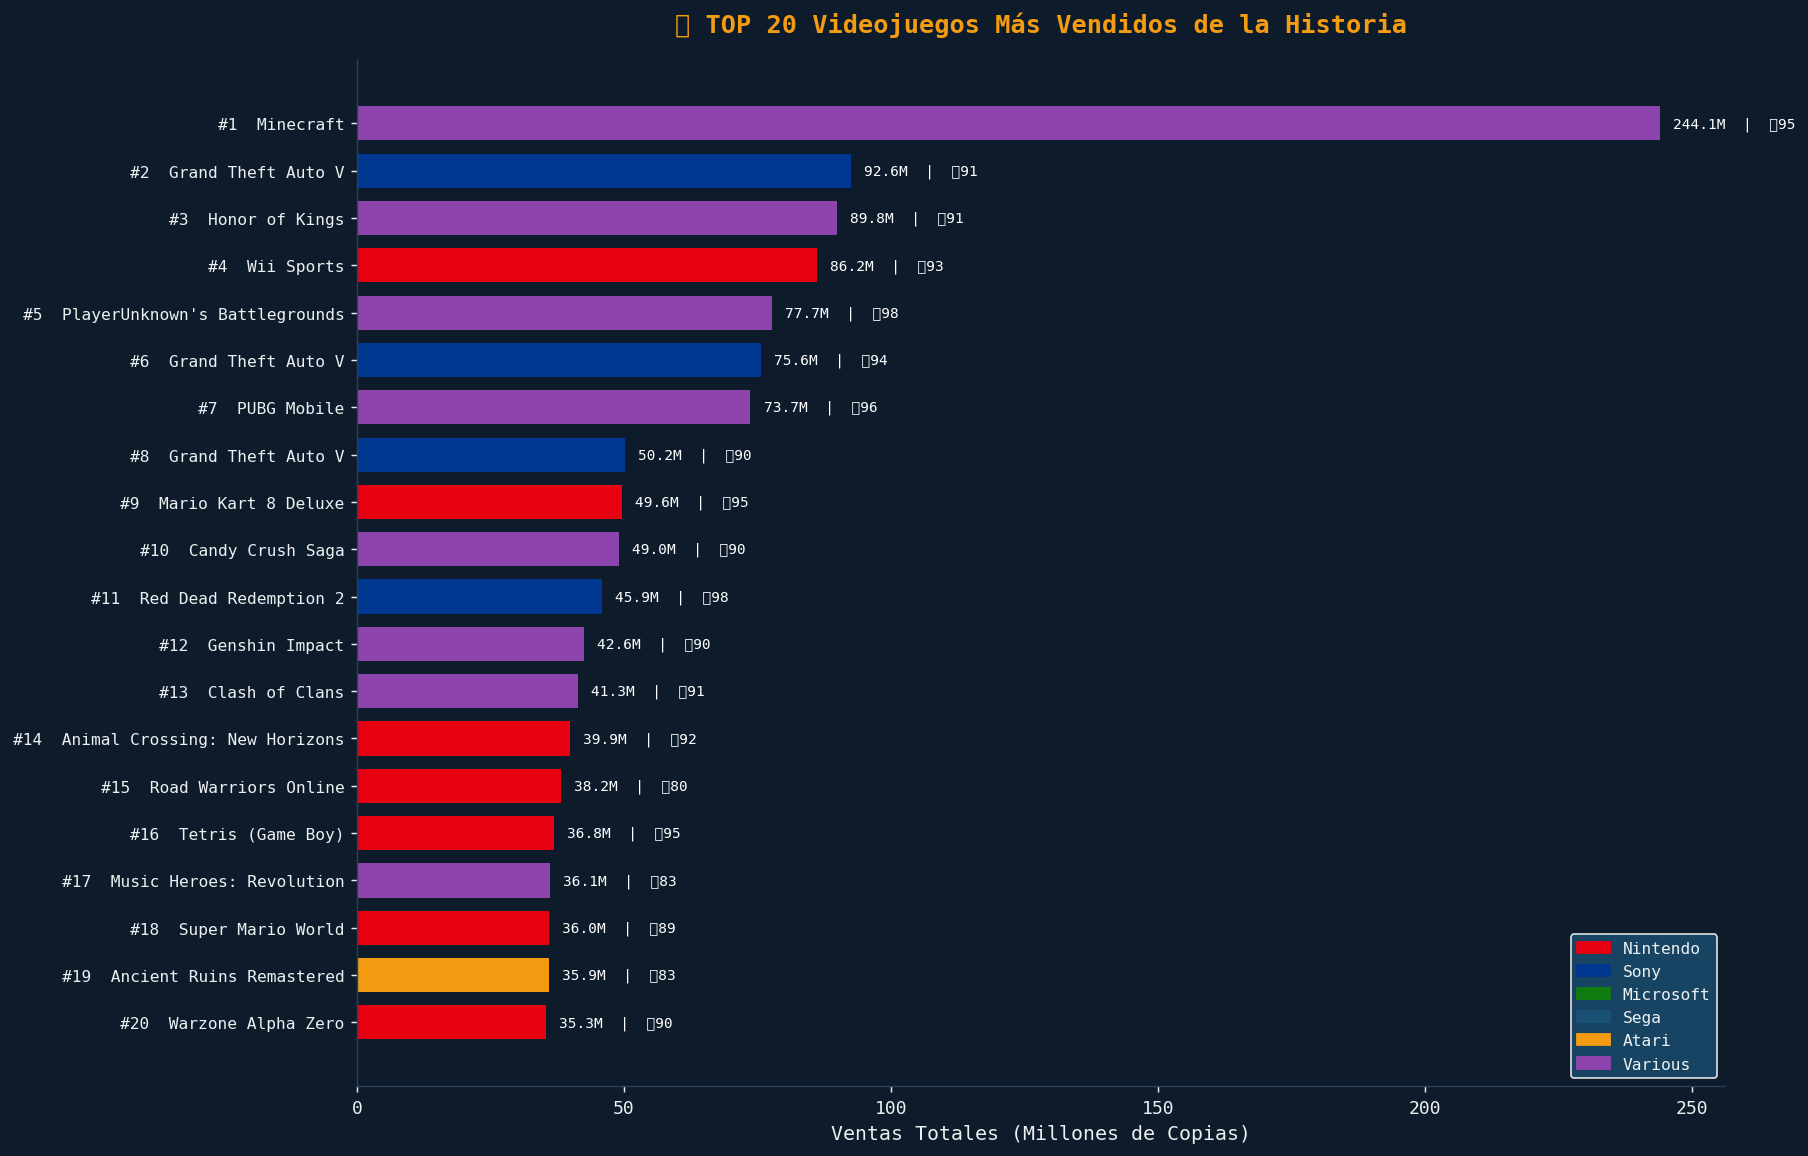

In [27]:
# TOP 20 Juegos más vendidos 
top20 = df.nlargest(20, COL['ventas_total'])[[
    COL['titulo'], COL['consola'], COL['grupo_pub'], COL['genero'],
    COL['anio_juego'], COL['ventas_total'], COL['score_critico']
]].reset_index(drop=True)
top20.index = top20.index + 1
top20.index.name = 'Rank'

fig, ax = plt.subplots(figsize=(14, 9))

colors_rank = []
for title in top20[COL['titulo']]:
    match = df[df[COL['titulo']] == title]
    brand = match[COL['marca']].iloc[0] if len(match) > 0 else 'Various'
    colors_rank.append(PALETTE_BRANDS.get(brand, '#555'))

bars = ax.barh(range(len(top20)), top20[COL['ventas_total']],
               color=colors_rank, edgecolor='none', height=0.72)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(
    [f"#{i+1}  {t}" for i, t in enumerate(top20[COL['titulo']])],
    fontsize=9
)
ax.invert_yaxis()

for bar, val, score in zip(bars, top20[COL['ventas_total']], top20[COL['score_critico']]):
    ax.text(val + top20[COL['ventas_total']].max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M  |  ⭐{score:.0f}',
            va='center', fontsize=8, color='white')

ax.set_xlabel('Ventas Totales (Millones de Copias)', fontsize=11)
ax.set_title('🏆 TOP 20 Videojuegos Más Vendidos de la Historia',
             fontsize=14, fontweight='bold', color=GOLD, pad=15)

legend_patches = [mpatches.Patch(color=v, label=k) for k,v in PALETTE_BRANDS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          facecolor='#1B4F72', edgecolor='white')
plt.tight_layout()
plt.show()


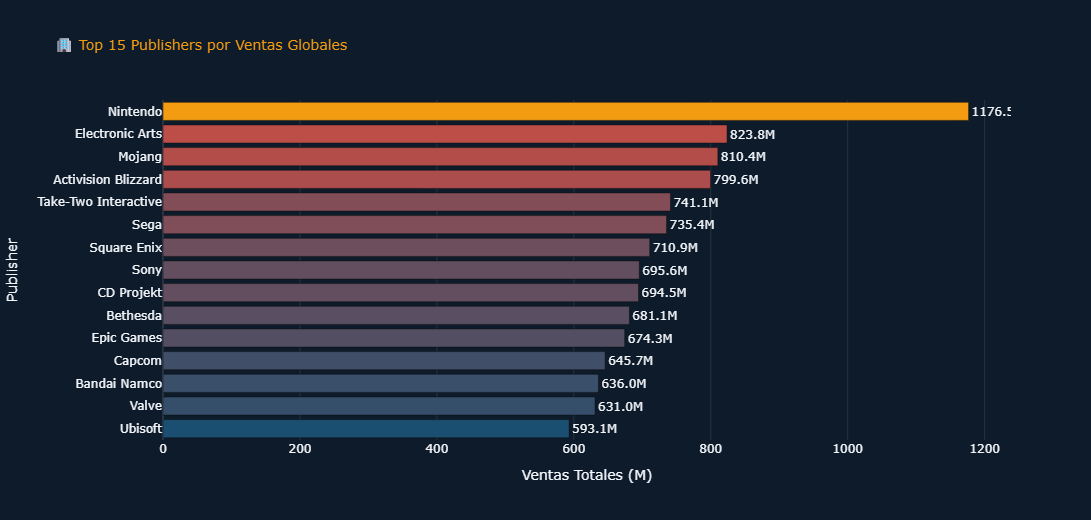

In [28]:
# Top Publishers por ventas totales 
top_pub = (df.groupby(COL['grupo_pub'])[COL['ventas_total']]
           .sum().sort_values(ascending=False).head(15))

fig = px.bar(
    top_pub.reset_index(),
    x=COL['ventas_total'], y=COL['grupo_pub'],
    orientation='h',
    color=COL['ventas_total'],
    color_continuous_scale=['#1B4F72','#E74C3C','#F39C12'],
    title='🏢 Top 15 Publishers por Ventas Globales',
    labels={COL['ventas_total']: 'Ventas Totales (M)',
            COL['grupo_pub']:    'Publisher'},
    template='plotly_dark',
    text=COL['ventas_total'],
)
fig.update_traces(texttemplate='%{text:.1f}M', textposition='outside')
fig.update_layout(
    paper_bgcolor='#0D1B2A', plot_bgcolor='#0D1B2A',
    title_font_color=GOLD, title_font_size=14,
    yaxis={'categoryorder':'total ascending'},
    height=520, coloraxis_showscale=False,
)
fig.show()


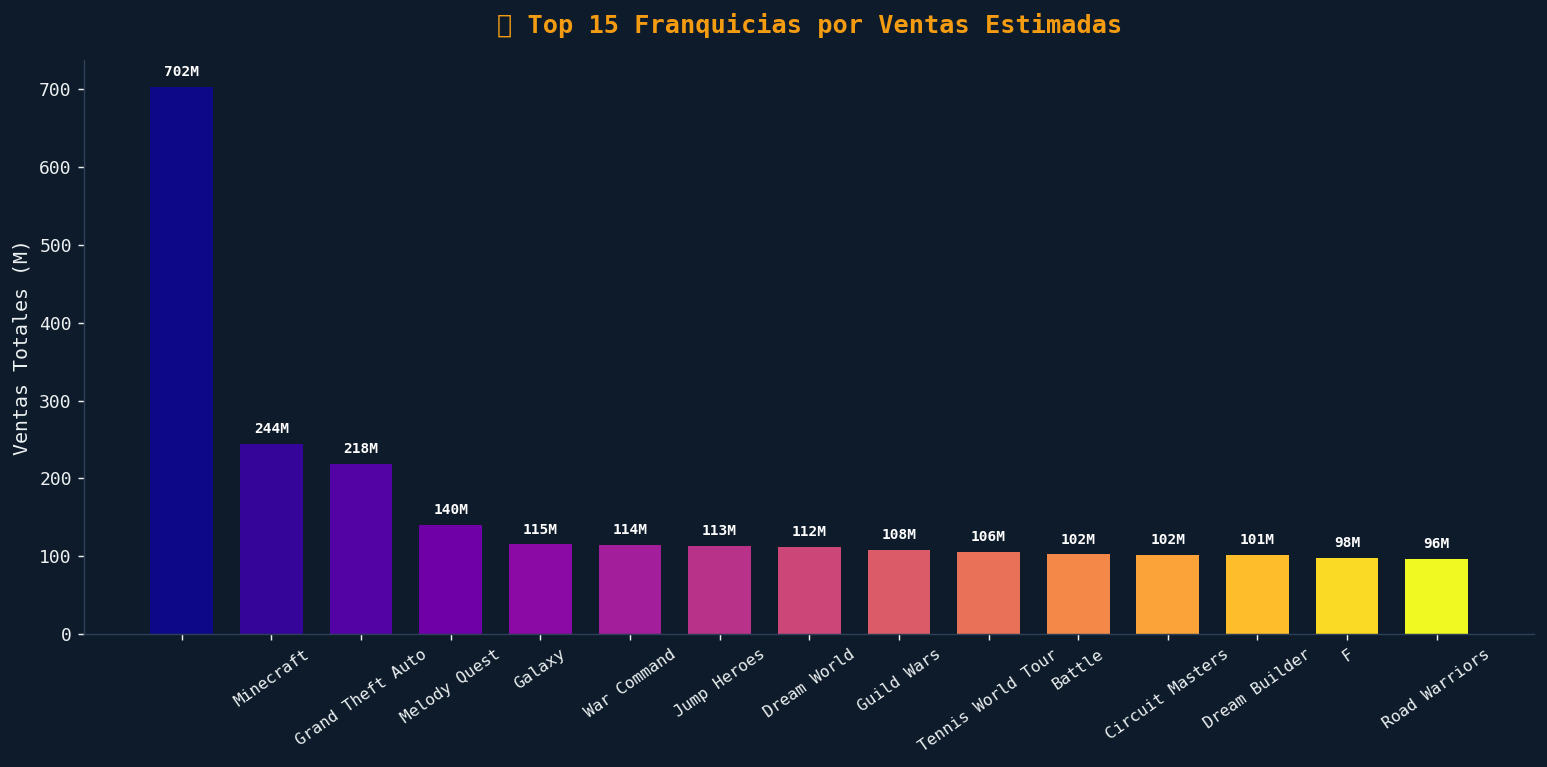

In [29]:
# Top franquicias estimadas
import re

def extraer_franquicia(titulo):
    # Extraer la raíz del nombre antes de números, ':' o sufijos comunes
    m = re.match(r'^(.*?)(?:\s*[IVX\d]+|:\s|\sRemaster|\sOrigins|\sLegacy|\sHD|\sDX|\sOnline|\s-)', str(titulo))
    if m:
        return m.group(1).strip()
    return str(titulo).strip()

df['_franquicia'] = df[COL['titulo']].apply(extraer_franquicia)
franchise_sales = (df.groupby('_franquicia')[COL['ventas_total']]
                   .sum().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(12, 6))
cmap_f = plt.cm.get_cmap('plasma', len(franchise_sales))
bars_f = ax.bar(franchise_sales.index, franchise_sales.values,
                color=[cmap_f(i) for i in range(len(franchise_sales))],
                edgecolor='none', width=0.7)
ax.set_title('🎮 Top 15 Franquicias por Ventas Estimadas',
             fontsize=14, fontweight='bold', color=GOLD, pad=15)
ax.set_ylabel('Ventas Totales (M)', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=9)

for bar, val in zip(bars_f, franchise_sales.values):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + franchise_sales.max() * 0.02,
            f'{val:.0f}M', ha='center', fontsize=8,
            color='white', fontweight='bold')
plt.tight_layout()
plt.show()


## 📊 Sección 9 — Dashboard Ejecutivo Gaming

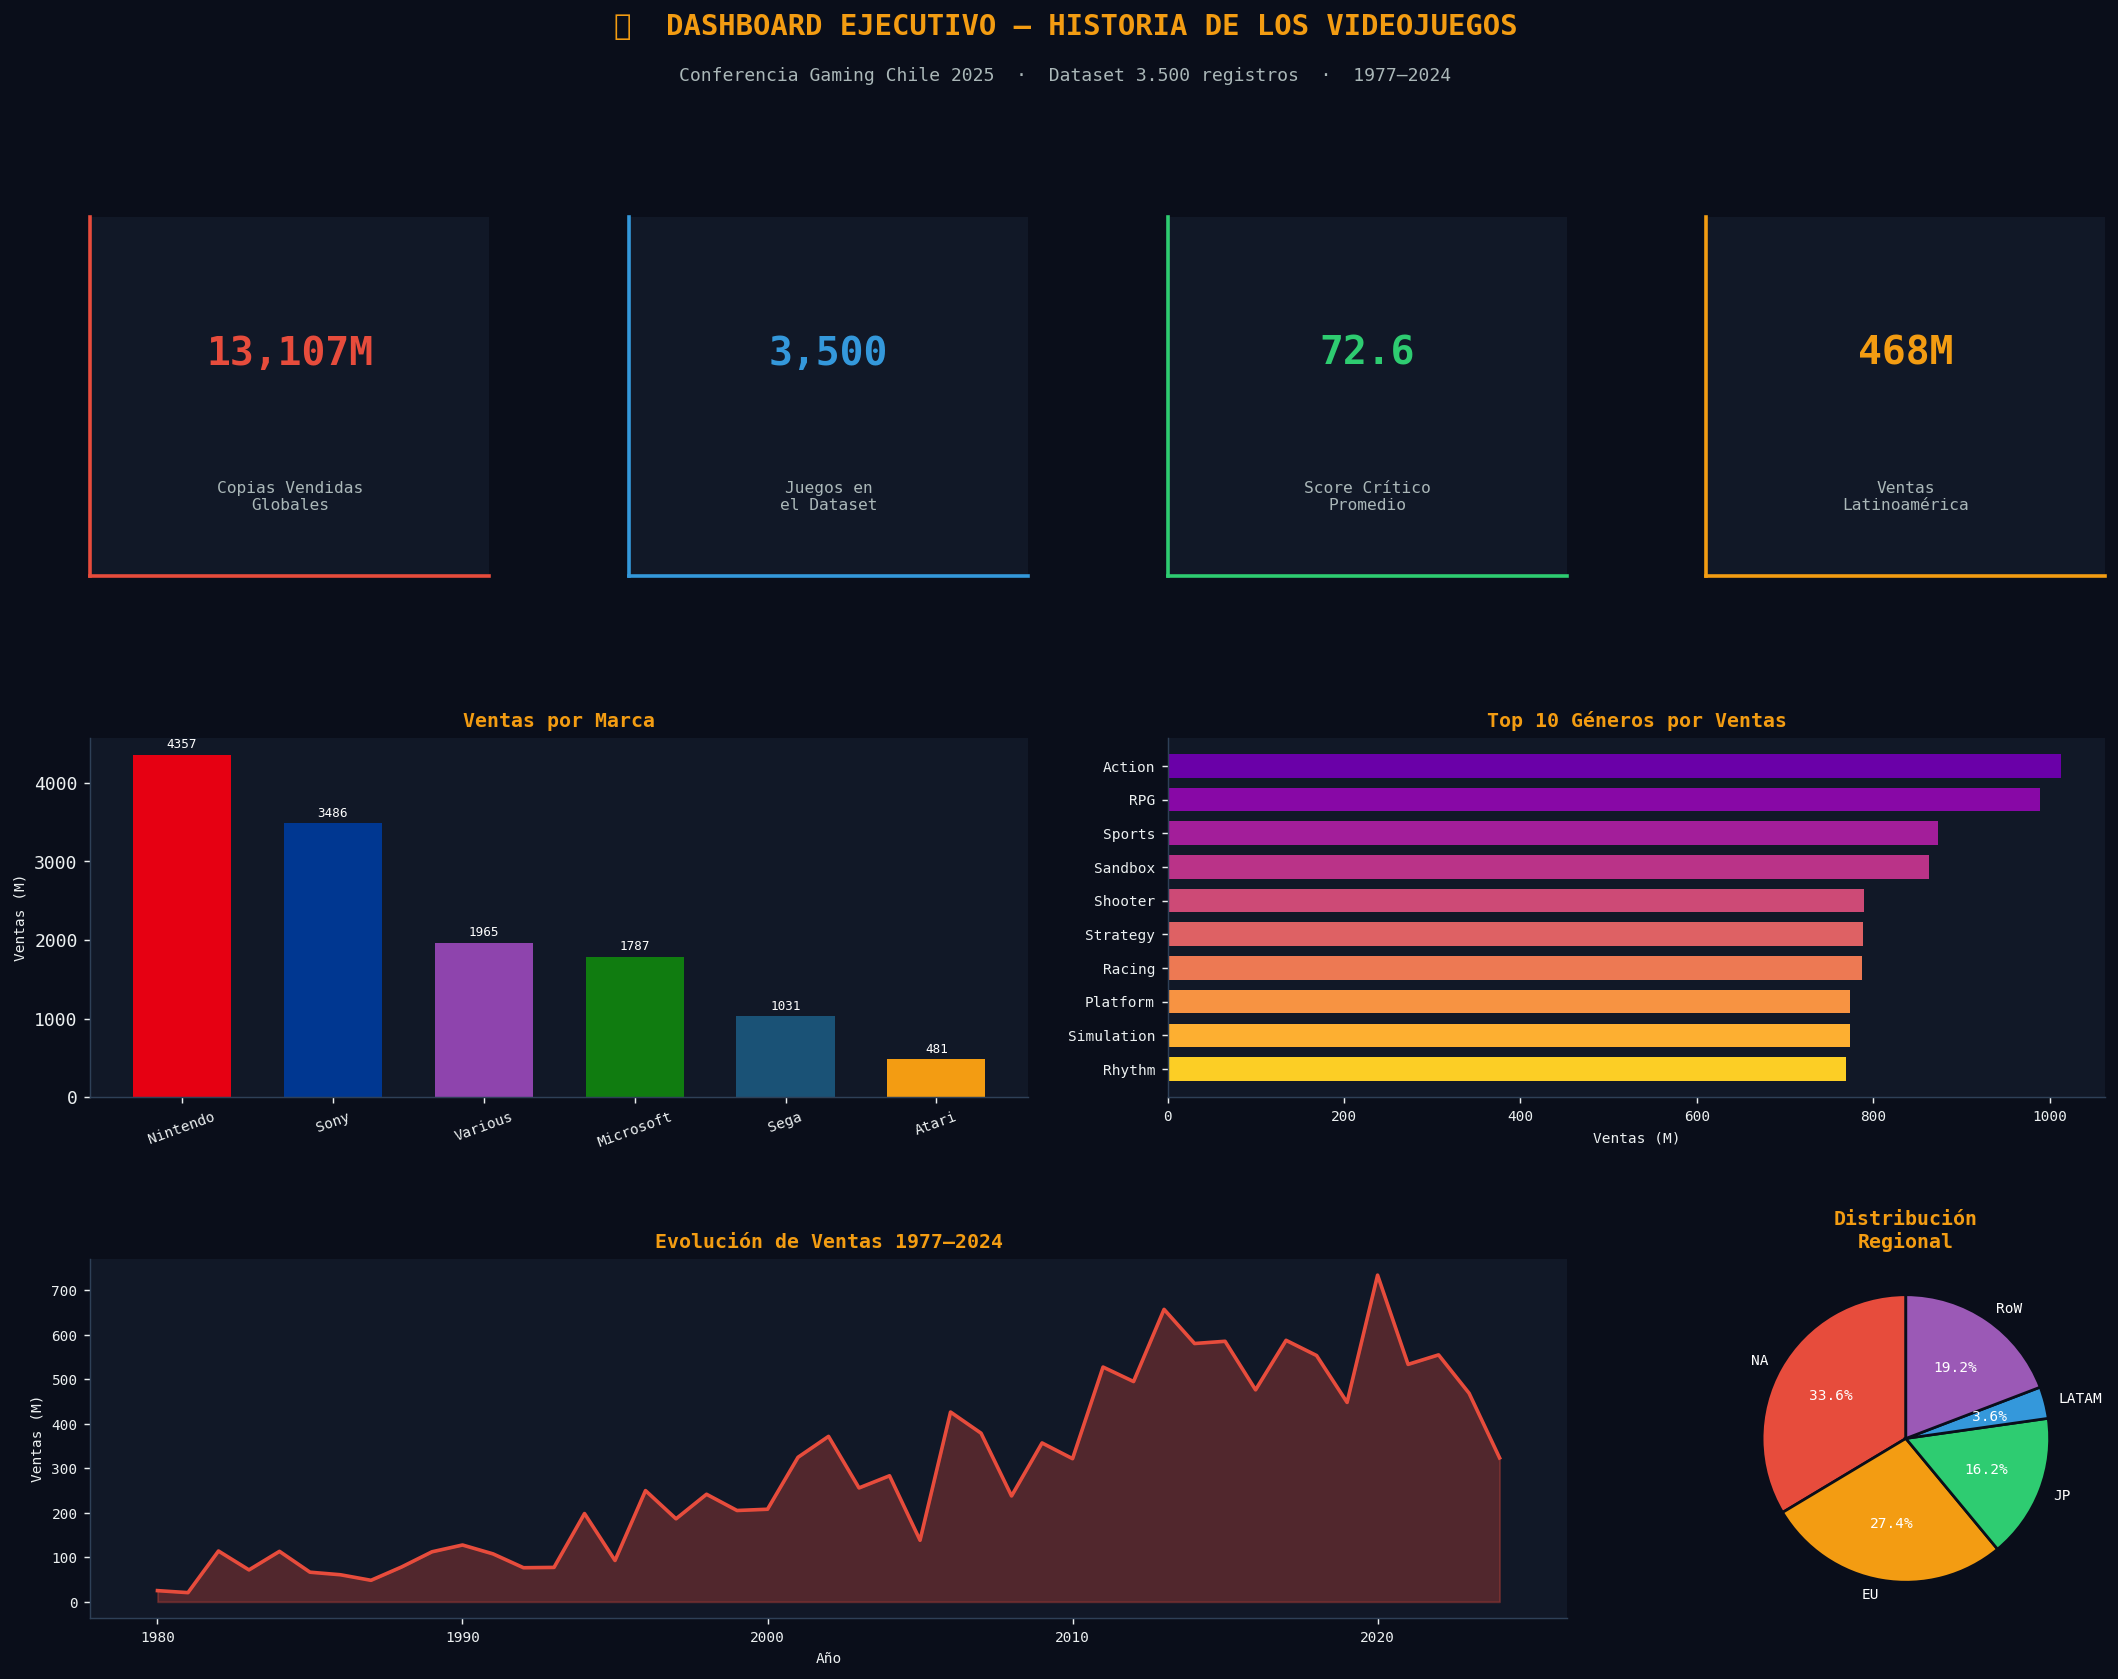


✅ Dashboard guardado como 'dashboard_gaming_chile.png'


In [30]:
# Dashboard multi-panel profesional
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0A0E1A')
gs_layout = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# KPI Cards (fila 0) 
kpis = [
    (f"{df[COL['ventas_total']].sum():,.0f}M",  "Copias Vendidas\nGlobales",    RED),
    (f"{len(df):,}",                             "Juegos en\nel Dataset",        BLUE),
    (f"{df[COL['score_critico']].mean():.1f}",  "Score Crítico\nPromedio",      '#2ECC71'),
    (f"{df[COL['ventas_latam']].sum():.0f}M",   "Ventas\nLatinoamérica",        GOLD),
]
for i, (val, label, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs_layout[0, i])
    ax_kpi.set_facecolor('#111827')
    ax_kpi.set_xlim(0,1); ax_kpi.set_ylim(0,1)
    ax_kpi.text(0.5, 0.62, val, ha='center', va='center',
                fontsize=22, fontweight='bold', color=color,
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.22, label, ha='center', va='center',
                fontsize=9, color='#AAB7B8', transform=ax_kpi.transAxes)
    for spine in ax_kpi.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])

# ── Ventas por Marca (fila 1, col 0-1) 
ax1 = fig.add_subplot(gs_layout[1, 0:2])
ax1.set_facecolor('#111827')
bs = df.groupby(COL['marca'])[COL['ventas_total']].sum().sort_values(ascending=False)
colors_b2 = [PALETTE_BRANDS.get(b,'#555') for b in bs.index]
bars1 = ax1.bar(bs.index, bs.values, color=colors_b2, edgecolor='none', width=0.65)
ax1.set_title('Ventas por Marca', fontsize=11, fontweight='bold', color=GOLD)
ax1.set_ylabel('Ventas (M)', fontsize=8)
ax1.tick_params(axis='x', rotation=20, labelsize=8)
for b2, v in zip(bars1, bs.values):
    ax1.text(b2.get_x()+b2.get_width()/2, b2.get_height()+bs.max()*0.02,
             f'{v:.0f}', ha='center', fontsize=7, color='white')

# ── Ventas por Género (fila 1, col 2-3) 
ax2 = fig.add_subplot(gs_layout[1, 2:4])
ax2.set_facecolor('#111827')
gs2 = df.groupby(COL['genero'])[COL['ventas_total']].sum().sort_values(ascending=False).head(10)
cmap2 = plt.cm.plasma(np.linspace(0.2, 0.9, len(gs2)))
bars2 = ax2.barh(gs2.index, gs2.values, color=cmap2, edgecolor='none', height=0.7)
ax2.invert_yaxis()
ax2.set_title('Top 10 Géneros por Ventas', fontsize=11, fontweight='bold', color=GOLD)
ax2.set_xlabel('Ventas (M)', fontsize=8)
ax2.tick_params(labelsize=8)

# ── Evolución temporal (fila 2, col 0-2) 
ax3 = fig.add_subplot(gs_layout[2, 0:3])
ax3.set_facecolor('#111827')
yd = df.groupby(COL['anio_juego'])[COL['ventas_total']].sum().sort_index()
ax3.fill_between(yd.index, yd.values, alpha=0.3, color=RED)
ax3.plot(yd.index, yd.values, color=RED, linewidth=2)
ax3.set_title('Evolución de Ventas 1977–2024', fontsize=11, fontweight='bold', color=GOLD)
ax3.set_ylabel('Ventas (M)', fontsize=8)
ax3.set_xlabel('Año', fontsize=8)
ax3.tick_params(labelsize=8)

# ── Pie regional (fila 2, col 3) 
ax4 = fig.add_subplot(gs_layout[2, 3])
ax4.set_facecolor('#111827')
reg_totals = {
    'NA':    df[COL['ventas_na']].sum(),
    'EU':    df[COL['ventas_eu']].sum(),
    'JP':    df[COL['ventas_jp']].sum(),
    'LATAM': df[COL['ventas_latam']].sum(),
    'RoW':   df[COL['ventas_row']].sum(),
}
ax4.pie(reg_totals.values(), labels=reg_totals.keys(),
        colors=PALETTE_MAIN[:5], autopct='%1.1f%%',
        startangle=90, textprops={'color':'white','fontsize':8},
        wedgeprops={'edgecolor':'#0A0E1A','linewidth':1.5})
ax4.set_title('Distribución\nRegional', fontsize=11, fontweight='bold', color=GOLD)

# Título general
fig.text(0.5, 0.98, '🎮  DASHBOARD EJECUTIVO — HISTORIA DE LOS VIDEOJUEGOS',
         ha='center', fontsize=16, fontweight='bold',
         color=GOLD, fontfamily='monospace')
fig.text(0.5, 0.955,
         'Conferencia Gaming Chile 2025  ·  Dataset 3.500 registros  ·  1977–2024',
         ha='center', fontsize=10, color='#AAB7B8')

plt.savefig('dashboard_gaming_chile.png', dpi=150, bbox_inches='tight',
            facecolor='#0A0E1A', edgecolor='none')
plt.show()
print("\n✅ Dashboard guardado como 'dashboard_gaming_chile.png'")


## 💾 Sección 10 — Exportación de Datos

In [31]:
# ── Exportar CSV principal (para Power BI) 
OUTPUT_DIR = r"C:\Documentos_Total\proyectos_26\videosjuegos_historicos\\"

df.to_csv(OUTPUT_DIR + "videojuegos_para_powerbi.csv",
          index=False, encoding='utf-8-sig')
print(f"✅ CSV exportado: {OUTPUT_DIR}videojuegos_para_powerbi.csv")

# ── Exportar JSON 
df.to_json(OUTPUT_DIR + "videojuegos_dataset.json",
           orient='records', force_ascii=False, indent=2)
print(f"✅ JSON exportado: {OUTPUT_DIR}videojuegos_dataset.json")

# ── Resumen Marca × Género 
summary1 = df.groupby([COL['marca'], COL['genero']]).agg(
    ventas_total = (COL['ventas_total'],  'sum'),
    n_juegos     = (COL['id'],            'count'),
    score_prom   = (COL['score_critico'], 'mean'),
).reset_index()
summary1.to_csv(OUTPUT_DIR + "resumen_marca_genero.csv",
                index=False, encoding='utf-8-sig')

# ── Serie temporal 
summary2 = df.groupby([COL['anio_juego'], COL['marca'], COL['tipo_consola']]).agg(
    ventas_total = (COL['ventas_total'], 'sum'),
    n_juegos     = (COL['id'],           'count'),
).reset_index()
summary2.to_csv(OUTPUT_DIR + "serie_temporal.csv",
                index=False, encoding='utf-8-sig')

# ── Top 100 
top100 = df.nlargest(100, COL['ventas_total']).reset_index(drop=True)
top100.index += 1
top100.to_csv(OUTPUT_DIR + "top100_juegos.csv",
              index_label='rank', encoding='utf-8-sig')

print("\n✅ Archivos para Power BI generados exitosamente:")
print(f"   📄 videojuegos_para_powerbi.csv  — Dataset principal ({len(df):,} filas)")
print(f"   📄 resumen_marca_genero.csv      — Para gráfico de matriz")
print(f"   📄 serie_temporal.csv            — Para gráfico de líneas")
print(f"   📄 top100_juegos.csv             — Para tabla de ranking")
print(f"   📄 videojuegos_dataset.json      — Formato JSON")



✅ CSV exportado: C:\Documentos_Total\proyectos_26\videosjuegos_historicos\\videojuegos_para_powerbi.csv
✅ JSON exportado: C:\Documentos_Total\proyectos_26\videosjuegos_historicos\\videojuegos_dataset.json

✅ Archivos para Power BI generados exitosamente:
   📄 videojuegos_para_powerbi.csv  — Dataset principal (3,500 filas)
   📄 resumen_marca_genero.csv      — Para gráfico de matriz
   📄 serie_temporal.csv            — Para gráfico de líneas
   📄 top100_juegos.csv             — Para tabla de ranking
   📄 videojuegos_dataset.json      — Formato JSON


In [33]:
# ── Reporte HTML con ydata-profiling ─────────────────────
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Reporte Videojuegos — Conferencia Gaming Chile 2025",
    explorative=True,
)

report_path = OUTPUT_DIR + "reporte_eda_videojuegos.html"
profile.to_file(report_path)
print(f"✅ Reporte HTML generado: {report_path}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 33/33 [00:00<00:00, 727.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Reporte HTML generado: C:\Documentos_Total\proyectos_26\videosjuegos_historicos\\reporte_eda_videojuegos.html


In [32]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


---
<div style="background: linear-gradient(135deg, #0D1B2A, #1B4F72);
     padding: 30px; border-radius: 12px; text-align: center;
     border: 1px solid #E74C3C;">
  <h2 style="color: #F39C12; font-family: monospace; margin: 0 0 12px 0;">
    🎮 ANÁLISIS COMPLETADO
  </h2>
  <p style="color: #ECF0F1; margin: 0 0 8px 0; font-size: 14px;">
    <strong>Practica Datos Gaming Chile 2025</strong><br>
    <strong>Autor: Cristopher Jiménez Escobar - Analista / Cientifico de Datos</strong><br>
    Dataset: 3.500 registros · 32 variables · 1977–2024
  </p>
  <hr style="border-color: #E74C3C; width: 50%; margin: 16px auto;">
  <p style="color: #AAB7B8; font-size: 12px; margin: 0;">
    Python · Pandas · Matplotlib · Seaborn · Plotly · SciPy<br>
    Fuentes: VGChartz · IGDB · Metacritic · 2024
  </p>
</div>